# Validation of `wfs_live` Script 

Created: May 2026 · Last updated: 2026-06-01

Author: Wei "Francis" He (francisho@lbl.gov / whorwhey@gmail.com)

___

## Overview

Validation of `wfs_live.py`, including regression checks on its successive improvements.

__Data:__
- **Synthetic data.** Clean interferogram built from the sim-notebook recipe.
- **Real data #1 — COSMIC.** Older measurements at the COSMIC beamline. Clean fringes and a relatively simple wavefront; good for end-to-end sanity.
- **Real data #2 — BL 5.3.1.** Hard X-ray (7–9 keV) frames. Harder to reconstruct, which makes them the right stress test for the script.

__Conventions:__
- All phases in radians
- All lengths in meters (SI)

__References:__
- Code adapted from [Xiaoya and Antoine's notebooks](https://github.com/dream-beam/dream-test/blob/main/wavefront_sim/)
- Wojdyla et al., 2018
- Goldberg et al., 2021 & 2023

__Requirements:__
- `monoplus.py` — Fresnel propagation library (`propTF`, `gaussfunc`, 
  `focus`, `polyfunc`, `secondmomt`)
- `wfs_live.py` — wavefront reconstruction pipeline under test

# SETUP 

## Import library 

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from PIL import Image

from tiled.client import from_uri
import os


In [2]:
import wfs_live as wfs
from monoplus import propTF, gaussfunc


In [78]:
import warnings
warnings.simplefilter('always', RuntimeWarning)

# TEST, with Simulated Data

Build a clean interferogram (sim-notebook recipe, no intermediate plotting), then run every primitive on it. 
- Tier 1: one-glance smoke per primitive. 
- Tier 2: `build_caustic_amplitude` deep dive (6 items). 

**Reference comparison.** Recovered focus is compared against the physical ground truth:
- `z_focus_GT = -(z_to_grating + z_T) = -2.400 m`
- `σ_focus_GT = source_sigma_m ≈ 4.247 µm` (intensity sigma at the source waist)

For `'field_envelope'` mode on aberration-free synthetic data, expect Δz at the mm scale and Δσ within ~10% of GT. Larger deviations point to real reconstruction error, not a regression failure.

## Building Synthetic Interferogram


In [36]:
# Physical parameters
energy_eV       = 500.0
wavelength_m    = 1.23984e-6 / energy_eV
z_to_grating_m  = 2.0
z_T_m           = 0.4
grating_pitch_m = np.sqrt(z_T_m * wavelength_m)   # plane-wave Talbot

# Source (Gaussian, defined by intensity FWHM)
source_fwhm_m  = 10e-6
source_sigma_m = source_fwhm_m / (2*np.sqrt(2*np.log(2)))

# Computational grid
M    = 100000
L_m  = 2e-3
dx_m = L_m / M
x_m  = np.linspace(-L_m/2, L_m/2, M)

print(f"λ = {wavelength_m*1e9:.3f} nm   ({energy_eV:.0f} eV)")
print(f"Geometry: source → grating ({z_to_grating_m} m) → detector ({z_T_m} m)")
print(f"Pitch:    {grating_pitch_m*1e6:.2f} µm")
print(f"Grid:     {L_m*1e3:.1f} mm, dx = {dx_m*1e6:.3f} µm ({M} pts)")

λ = 2.480 nm   (500 eV)
Geometry: source → grating (2.0 m) → detector (0.4 m)
Pitch:    31.49 µm
Grid:     2.0 mm, dx = 0.020 µm (100000 pts)


In [37]:
# Source → grating → modulate → detector (no intermediate plots)
E_source        = gaussfunc(x_m, mean_x=0, sigma_x=source_sigma_m)
E_at_grating    = propTF(E_source, L_m, wavelength_m, z_to_grating_m)
grating_pattern = (np.sign(np.sin(2*np.pi * x_m / grating_pitch_m)) + 1) / 2
E_modulated     = E_at_grating * grating_pattern
E_at_z_T        = propTF(E_modulated, L_m, wavelength_m, z_T_m)
I_at_z_T        = np.abs(E_at_z_T)**2

# Fringe contrast on a central window (V is undefined in the dark wings)
half_w   = M // 20                                          # central ±100 µm
core     = slice(M//2 - half_w, M//2 + half_w)
I_core   = I_at_z_T[core]
contrast = (I_core.max() - I_core.min()) / (I_core.max() + I_core.min())

print(f"I_at_z_T: shape {I_at_z_T.shape}")
print(f"Central ±{half_w*dx_m*1e6:.0f} µm fringe contrast: {contrast:.4f}")

I_at_z_T: shape (100000,)
Central ±100 µm fringe contrast: 0.9894


img_synth: shape (100, 100000)
y_roi: slice(0, 100, None), axis: 0


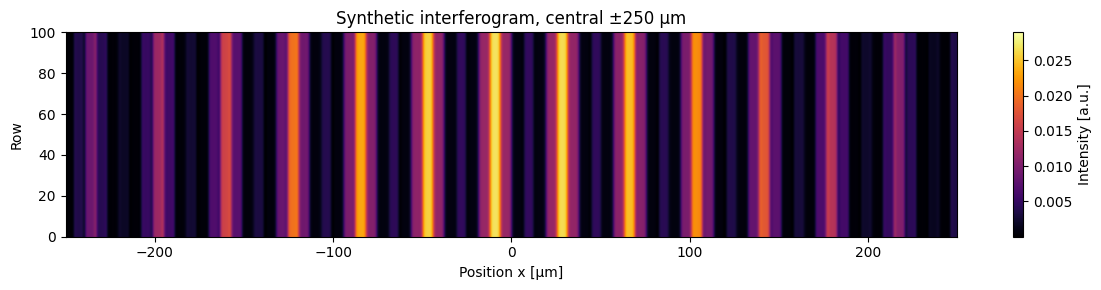

In [38]:
# Tile 1D interferogram into a 2D pseudo-camera frame for extract_profile testing
n_rows    = 100
img_synth = np.tile(I_at_z_T[None, :], (n_rows, 1))   # shape (n_rows, M)

# Standing ROI / axis convention for the rest of Stage A
y_roi = slice(0, n_rows)
axis  = 0                                              # average over rows

print(f"img_synth: shape {img_synth.shape}")
print(f"y_roi: {y_roi}, axis: {axis}")

# Visualize central ±250 µm (≈ 16 fringe periods)
half_w_disp = M // 8                                   # central ±250 µm
disp_slice  = slice(M//2 - half_w_disp, M//2 + half_w_disp)
x_disp_um   = x_m[disp_slice] * 1e6

fig, ax = plt.subplots(figsize=(12, 3))
im = ax.imshow(img_synth[:, disp_slice],
               extent=[x_disp_um[0], x_disp_um[-1], 0, n_rows],
               aspect='auto', cmap='inferno', origin='lower')
ax.set_xlabel('Position x [µm]')
ax.set_ylabel('Row')
ax.set_title(f'Synthetic interferogram, central ±{half_w_disp*dx_m*1e6:.0f} µm')
plt.colorbar(im, ax=ax, label='Intensity [a.u.]')
plt.tight_layout()
plt.show()

## Phase Reconstruction

Run each primitive in turn on the synthetic frame, then a focused workout on `build_caustic_amplitude`.

In [39]:
profile = wfs.extract_profile(img_synth, y_roi, axis=axis)

print(f"profile shape   : {profile.shape}  (expected ({img_synth.shape[1]},))")
print(f"max |diff| vs I_at_z_T: {np.max(np.abs(profile - I_at_z_T)):.2e}")

profile shape   : (100000,)  (expected (100000,))
max |diff| vs I_at_z_T: 6.94e-17


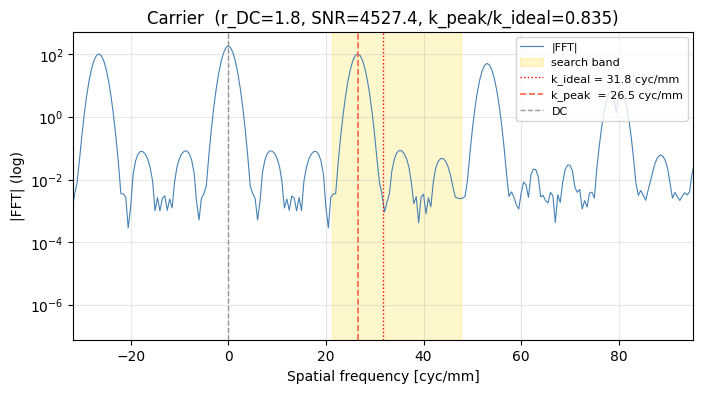

k_ideal (1/p)       : 31.752 cyc/mm
Search band         : [21.168, 47.628] cyc/mm
k_peak (measured)   : 26.500 cyc/mm
k_peak / k_ideal    : 0.83459
k_amp               : 1.034e+02


In [40]:
carrier = wfs.find_carrier(profile, dx_m, grating_pitch_m, band_factor=1.5, plot=True)

print(f"k_ideal (1/p)       : {carrier['k_ideal']*1e-3:.3f} cyc/mm")
print(f"Search band         : [{carrier['band'][0]*1e-3:.3f}, "
      f"{carrier['band'][1]*1e-3:.3f}] cyc/mm")
print(f"k_peak (measured)   : {carrier['k_peak']*1e-3:.3f} cyc/mm")
print(f"k_peak / k_ideal    : {carrier['k_peak']/carrier['k_ideal']:.5f}")
print(f"k_amp               : {carrier['k_amp']:.3e}")

# # |FFT_avg| with search band shaded, k_peak marked
# freq      = carrier['freq']
# fft_mag   = np.abs(carrier['fft_avg'])
# band_lo, band_hi = carrier['band']

# # positive-frequency side only, zoom around the carrier
# fmax_disp = 2 * carrier['k_ideal']
# pos = (freq > 0) & (freq < fmax_disp)

# fig, ax = plt.subplots(figsize=(9, 3.5))
# ax.semilogy(freq[pos]*1e-3, fft_mag[pos], lw=1)
# ax.axvspan(band_lo*1e-3, band_hi*1e-3, color='C1', alpha=0.2, label='search band')
# ax.axvline(carrier['k_ideal']*1e-3, color='gray', ls=':', label='k_ideal')
# ax.axvline(carrier['k_peak']*1e-3,  color='C3', ls='--', label='k_peak')
# ax.set_xlabel('Frequency [cyc/mm]')
# ax.set_ylabel('|FFT_avg|')
# ax.set_title('Carrier detection')
# ax.legend(loc='upper right', fontsize=9)
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [41]:
# DC / carrier ratio on Stage A clean synthetic — baseline for comparison
# against real-data Stage B value (which was 5.42).

fft_avg_synth = carrier['fft_avg']
freq_synth    = carrier['freq']

idx_dc      = int(np.argmin(np.abs(freq_synth)))
amp_dc      = float(np.abs(fft_avg_synth[idx_dc]))
amp_carrier = float(carrier['k_amp'])

print(f'— Stage A (clean synthetic) DC/carrier baseline —')
print(f'  |FFT(DC)|     : {amp_dc:.3g}')
print(f'  |FFT(k_peak)| : {amp_carrier:.3g}')
print(f'  DC / carrier  : {amp_dc/amp_carrier:.3f}')

# Cross-check against Phase G's library-computed values.
# find_carrier now returns dc_amp and bg_amp directly.
print()
print(f'  Library dc_amp  : {carrier["dc_amp"]:.3g}  '
      f'(manual: {amp_dc:.3g}, match: {np.isclose(carrier["dc_amp"], amp_dc)})')
print(f'  Library k_amp   : {carrier["k_amp"]:.3g}')
print(f'  Library bg_amp  : {carrier["bg_amp"]:.3g}  (new — Phase G)')
print(f'  → dc/carrier    : {carrier["dc_amp"]/carrier["k_amp"]:.3f}')
print(f'  → carrier_snr   : {carrier["k_amp"]/carrier["bg_amp"]:.1f}')

— Stage A (clean synthetic) DC/carrier baseline —
  |FFT(DC)|     : 188
  |FFT(k_peak)| : 103
  DC / carrier  : 1.820

  Library dc_amp  : 188  (manual: 188, match: True)
  Library k_amp   : 103
  Library bg_amp  : 0.0228  (new — Phase G)
  → dc/carrier    : 1.820
  → carrier_snr   : 4527.4


sigma_0 (0th order) : 5.300 cyc/mm
sigma_1 (+1 order)  : 2.650 cyc/mm
I0 range            : [3.179e-05, 8.894e-03]
A1 range            : [1.583e-09, 4.860e-03]


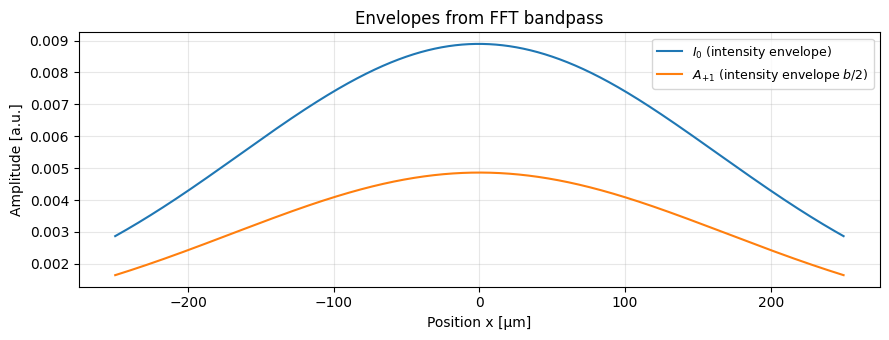

In [42]:
env = wfs.extract_envelopes(carrier['fft_avg'], carrier['freq'], carrier['k_peak'],
                            sigma_ratio_0=5, sigma_ratio_1=10)

print(f"sigma_0 (0th order) : {env['sigma_0']*1e-3:.3f} cyc/mm")
print(f"sigma_1 (+1 order)  : {env['sigma_1']*1e-3:.3f} cyc/mm")
print(f"I0 range            : [{env['I0'].min():.3e}, {env['I0'].max():.3e}]")
print(f"A1 range            : [{env['A1'].min():.3e}, {env['A1'].max():.3e}]")

# I0(x) and A1(x) overlaid, central ±250 µm crop
half_w_disp = M // 8
disp        = slice(M//2 - half_w_disp, M//2 + half_w_disp)
x_disp_um   = x_m[disp] * 1e6

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(x_disp_um, env['I0'][disp], lw=1.5, label='$I_0$ (intensity envelope)')
ax.plot(x_disp_um, env['A1'][disp], lw=1.5, label='$A_{+1}$ (intensity envelope $b/2$)')
ax.set_xlabel('Position x [µm]')
ax.set_ylabel('Amplitude [a.u.]')
ax.set_title('Envelopes from FFT bandpass')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
# Internal gaps
m1 = np.array([False, False, True, True, False, True, False, True, True, False, False])
print("internal gaps:")
print(f"  in : {m1.astype(int)}")
print(f"  out: {wfs.fill_mask_gaps(m1).astype(int)}")
print( "  expected: [0 0 1 1 1 1 1 1 1 0 0]")

# Edge cases
print(f"all False : {wfs.fill_mask_gaps(np.zeros(5, bool)).astype(int)}")
print(f"all True  : {wfs.fill_mask_gaps(np.ones(5, bool)).astype(int)}")
print(f"single Tr : {wfs.fill_mask_gaps(np.array([False, True, False])).astype(int)}")

internal gaps:
  in : [0 0 1 1 0 1 0 1 1 0 0]
  out: [0 0 1 1 1 1 1 1 1 0 0]
  expected: [0 0 1 1 1 1 1 1 1 0 0]
all False : [0 0 0 0 0]
all True  : [1 1 1 1 1]
single Tr : [0 1 0]


In [44]:
centroid = wfs.find_phase_centroid(env['I0'], env['A1'])

N           = profile.size
offset_px   = centroid['x_c'] - N // 2
offset_um   = offset_px * dx_m * 1e6

print(f"threshold (1/e²)     : {centroid['threshold']:.4f}")
print(f"mask pixels          : {centroid['n_mask_px']}  "
      f"({centroid['n_filled_px']} added by gap-fill)")
print(f"x_c                  : {centroid['x_c']}")
print(f"array midpoint N//2  : {N//2}")
print(f"offset (x_c − N//2)  : {offset_px:+d} px  ({offset_um:+.3f} µm)")

threshold (1/e²)     : 0.1353
mask pixels          : 33502  (0 added by gap-fill)
x_c                  : 50000
array midpoint N//2  : 50000
offset (x_c − N//2)  : +0 px  (+0.000 µm)


In [45]:
# Item 11 test: fill_gaps=True vs False on clean synthetic.
# Synthetic I0 has no interior gaps above threshold, so both branches
# should produce identical masks (n_filled_px=0 either way) and the
# same centroid. This confirms the new branch routes correctly without
# changing behavior on no-gap inputs.

cen_fill   = wfs.find_phase_centroid(env['I0'], env['A1'], fill_gaps=True)
cen_nofill = wfs.find_phase_centroid(env['I0'], env['A1'], fill_gaps=False)

print(f"fill_gaps=True  : n_mask_px={cen_fill['n_mask_px']}, "
      f"n_filled_px={cen_fill['n_filled_px']}, x_c={cen_fill['x_c']}")
print(f"fill_gaps=False : n_mask_px={cen_nofill['n_mask_px']}, "
      f"n_filled_px={cen_nofill['n_filled_px']}, x_c={cen_nofill['x_c']}")
print(f"\nExpected on clean synthetic:")
print(f"  n_filled_px = 0 in both (no interior gaps to fill)")
print(f"  x_c agrees  : {cen_fill['x_c'] == cen_nofill['x_c']}")
print(f"  masks agree : {np.array_equal(cen_fill['beam_mask'], cen_nofill['beam_mask'])}")

fill_gaps=True  : n_mask_px=33502, n_filled_px=0, x_c=50000
fill_gaps=False : n_mask_px=33502, n_filled_px=0, x_c=50000

Expected on clean synthetic:
  n_filled_px = 0 in both (no interior gaps to fill)
  x_c agrees  : True
  masks agree : True


W_rad range : [+0.000, +523.657] rad
W_nm  range : [+0.000, +206.663] nm


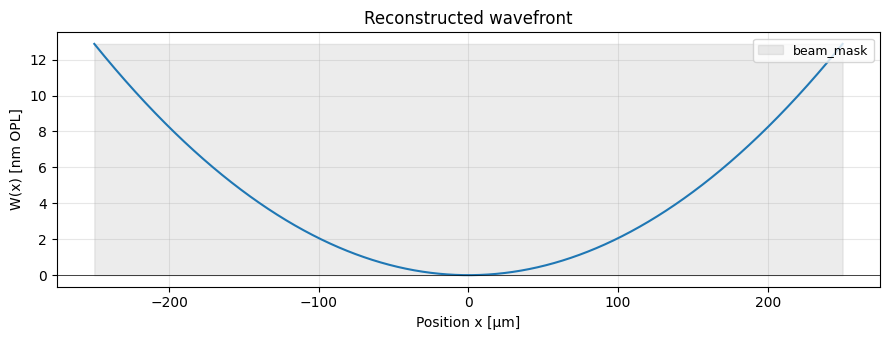

In [46]:
wfr = wfs.reconstruct_wavefront(
    env['complex_1st'], dx_m, grating_pitch_m, wavelength_m, z_T_m,
    x_c=centroid['x_c'],
)

W_nm = wfr['W_rad'] * wavelength_m / (2*np.pi) * 1e9

print(f"W_rad range : [{wfr['W_rad'].min():+.3f}, {wfr['W_rad'].max():+.3f}] rad")
print(f"W_nm  range : [{W_nm.min():+.3f}, {W_nm.max():+.3f}] nm")

# W(x) in nm OPL, central ±250 µm crop, with beam_mask shaded
half_w_disp = M // 8
disp        = slice(M//2 - half_w_disp, M//2 + half_w_disp)
x_disp_um   = x_m[disp] * 1e6
mask_disp   = centroid['beam_mask'][disp]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.fill_between(x_disp_um, W_nm[disp].min(), W_nm[disp].max(),
                where=mask_disp, color='gray', alpha=0.15, label='beam_mask')
ax.plot(x_disp_um, W_nm[disp], lw=1.5)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Position x [µm]')
ax.set_ylabel('W(x) [nm OPL]')
ax.set_title('Reconstructed wavefront')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

f_pred           : -2.4264 m
a2 (defocus)     : +5.2215e+08 rad/m²
RMS residual     : 0.0001 nm  (inside beam_mask)
PV  residual     : 0.0007 nm


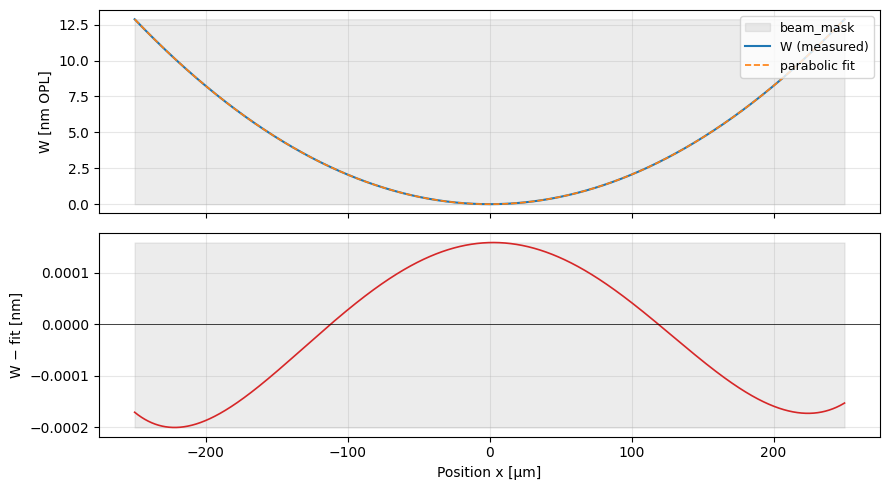

In [47]:
fit = wfs.parabolic_focal_fit(wfr['W_rad'], wfr['x_m'], wavelength_m,
                              mask=centroid['beam_mask'])

print(f"f_pred           : {fit['f_pred']:+.4f} m")
print(f"a2 (defocus)     : {fit['a2']:+.4e} rad/m²")
print(f"RMS residual     : {fit['rms_resid_nm']:.4f} nm  (inside beam_mask)")
print(f"PV  residual     : {fit['pv_resid_nm']:.4f} nm")

# W and parabolic fit overlaid, residual in second panel
W_para_nm  = fit['W_para_rad']  * wavelength_m / (2*np.pi) * 1e9
W_resid_nm = fit['W_resid_rad'] * wavelength_m / (2*np.pi) * 1e9

half_w_disp = M // 8
disp        = slice(M//2 - half_w_disp, M//2 + half_w_disp)
x_disp_um   = x_m[disp] * 1e6
mask_disp   = centroid['beam_mask'][disp]

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

axes[0].fill_between(x_disp_um, W_nm[disp].min(), W_nm[disp].max(),
                     where=mask_disp, color='gray', alpha=0.15, label='beam_mask')
axes[0].plot(x_disp_um, W_nm[disp],       lw=1.5, label='W (measured)')
axes[0].plot(x_disp_um, W_para_nm[disp],  lw=1.2, ls='--', label='parabolic fit')
axes[0].set_ylabel('W [nm OPL]')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(x_disp_um, W_resid_nm[disp].min(), W_resid_nm[disp].max(),
                     where=mask_disp, color='gray', alpha=0.15)
axes[1].plot(x_disp_um, W_resid_nm[disp], lw=1.2, color='C3')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('Position x [µm]')
axes[1].set_ylabel('W − fit [nm]')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Caustics

Scan z range: [-2.600, +0.100] m  (271 pts, step = 10.0 mm)

z_focus           : -2.4200 m
σ_focus           : 4.551 µm
Ground truth      : z = -2.400 m, σ = 4.247 µm
Deviation         : Δz = -20.0 mm  (+0.83%),  Δσ = +0.305 µm  (+7.17%)


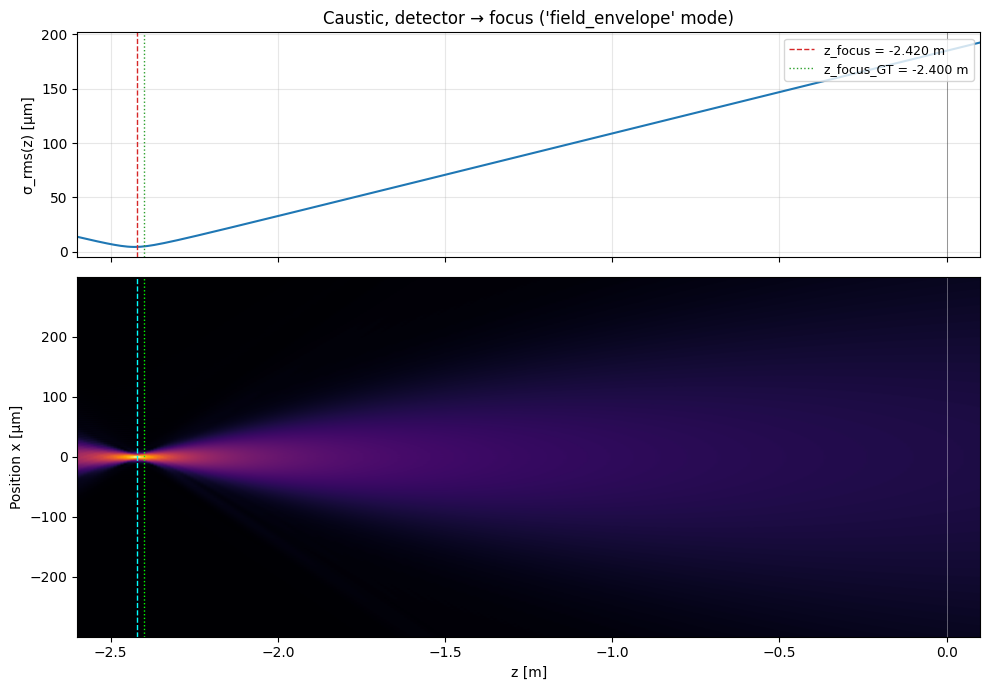

In [48]:
A_caustic = wfs.build_caustic_amplitude(env['I0'], env['A1'], mode='field_envelope')

# Scan from past-focus to past-detector
z_range_m = np.arange(-2.6, 0.1 + 1e-9, 0.01)         # 10 mm step
print(f"Scan z range: [{z_range_m[0]:+.3f}, {z_range_m[-1]:+.3f}] m  "
      f"({len(z_range_m)} pts, step = 10.0 mm)")

prop = wfs.propagate_to_focus(A_caustic, wfr['W_rad'], dx_m, wavelength_m,
                              z_range_m, x_m=wfr['x_m'],
                              f_pred_m=fit['f_pred'],
                              focus_search_halfwidth_m=0.2, focus_locator='fwhm_min')

# Ground-truth focus parameters (from sim geometry, not a previous run)
z_focus_GT     = -(z_to_grating_m + z_T_m)
sigma_focus_GT = source_sigma_m

print(f"\nz_focus           : {prop['z_focus']:+.4f} m")
print(f"σ_focus           : {prop['sigma_focus']*1e6:.3f} µm")
print(f"Ground truth      : z = {z_focus_GT:+.3f} m, σ = {sigma_focus_GT*1e6:.3f} µm")
print(f"Deviation         : Δz = {(prop['z_focus'] - z_focus_GT)*1e3:+.1f} mm  "
      f"({(prop['z_focus'] - z_focus_GT)/z_focus_GT*100:+.2f}%),  "
      f"Δσ = {(prop['sigma_focus'] - sigma_focus_GT)*1e6:+.3f} µm  "
      f"({(prop['sigma_focus'] - sigma_focus_GT)/sigma_focus_GT*100:+.2f}%)")

# x-crop for the 2D caustic
half_w_caustic = int(300e-6 / dx_m)
x_slice        = slice(M//2 - half_w_caustic, M//2 + half_w_caustic)
x_caustic_um   = wfr['x_m'][x_slice] * 1e6

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                         gridspec_kw={'height_ratios': [1, 1.6]})

# Top: σ(z)
axes[0].plot(prop['z_range_m'], prop['sigma_rms']*1e6, lw=1.5)
axes[0].axvline(prop['z_focus'], color='C3', ls='--', lw=1,
                label=f"z_focus = {prop['z_focus']:+.3f} m")
axes[0].axvline(z_focus_GT, color='C2', ls=':', lw=1,
                label=f"z_focus_GT = {z_focus_GT:+.3f} m")
axes[0].axvline(0, color='k', lw=0.5, alpha=0.5)
axes[0].set_ylabel('σ_rms(z) [µm]')
axes[0].set_title("Caustic, detector → focus ('field_envelope' mode)")
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Bottom: 2D caustic, sqrt-scaled for dynamic range
I_show = np.sqrt(prop['I_caustic'][x_slice, :])
extent = [prop['z_range_m'][0], prop['z_range_m'][-1],
          x_caustic_um[0], x_caustic_um[-1]]
im = axes[1].imshow(I_show, extent=extent, aspect='auto', origin='lower',
                    cmap='inferno')
axes[1].axvline(prop['z_focus'], color='cyan', ls='--', lw=1)
axes[1].axvline(z_focus_GT,      color='lime', ls=':',  lw=1)
axes[1].axvline(0, color='white', lw=0.5, alpha=0.5)
axes[1].set_xlabel('z [m]')
axes[1].set_ylabel('Position x [µm]')
# plt.colorbar(im, ax=axes[1], label='√Intensity [a.u.]')

plt.tight_layout()
plt.show()

x_c_focus (pixel)  : 49998  (x = -0.040 µm)
focus_mask px      : 531  (≈ 10.6 µm wide)
RMS at focus       : 0.0288 nm  (inside focus_mask)
PV  at focus       : 0.0905 nm


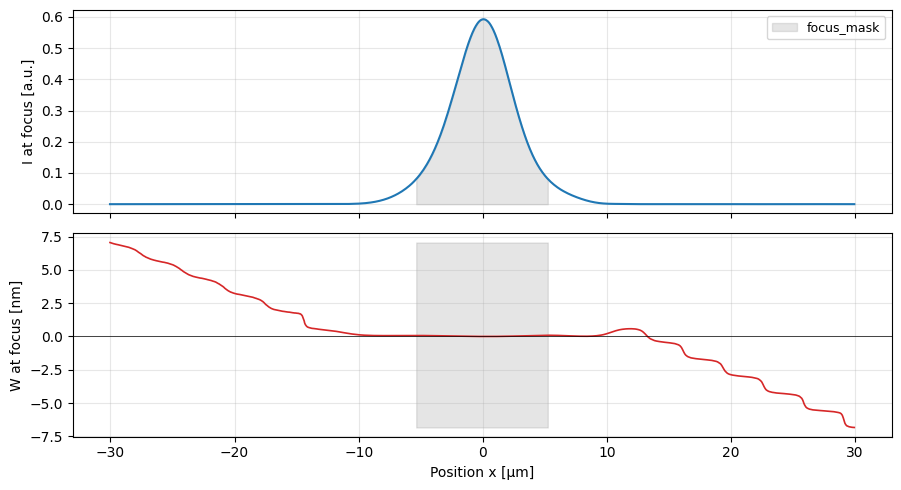

In [49]:
foc = wfs.wavefront_at_focus(prop, wavelength_m, dx_m)

x_focus_um = wfr['x_m'][foc['x_c_focus']] * 1e6

print(f"x_c_focus (pixel)  : {foc['x_c_focus']}  (x = {x_focus_um:+.3f} µm)")
print(f"focus_mask px      : {foc['focus_mask'].sum()}  "
      f"(≈ {foc['focus_mask'].sum() * dx_m * 1e6:.1f} µm wide)")
print(f"RMS at focus       : {foc['rms_at_focus_nm']:.4f} nm  (inside focus_mask)")
print(f"PV  at focus       : {foc['pv_at_focus_nm']:.4f} nm")

# Zoom: ±30 µm around the focus centroid
half_w_focus = int(30e-6 / dx_m)
foc_disp     = slice(foc['x_c_focus'] - half_w_focus,
                     foc['x_c_focus'] + half_w_focus)
x_foc_um     = wfr['x_m'][foc_disp] * 1e6
mask_foc     = foc['focus_mask'][foc_disp]

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

axes[0].fill_between(x_foc_um, 0, prop['I_focus'][foc_disp],
                     where=mask_foc, color='gray', alpha=0.2, label='focus_mask')
axes[0].plot(x_foc_um, prop['I_focus'][foc_disp], lw=1.5)
axes[0].set_ylabel('I at focus [a.u.]')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(x_foc_um, foc['W_focus_nm'][foc_disp].min(),
                                foc['W_focus_nm'][foc_disp].max(),
                     where=mask_foc, color='gray', alpha=0.2)
axes[1].plot(x_foc_um, foc['W_focus_nm'][foc_disp], lw=1.2, color='C3')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('Position x [µm]')
axes[1].set_ylabel('W at focus [nm]')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Caustic Amplitude Construction

`build_caustic_amplitude` builds the detector-plane amplitude `A(x)` that gets paired with the reconstructed wavefront `W(x)` to form `E_det = A · exp[i·W]` for Fresnel propagation to focus. Two modes:

| Mode | A(x) | Strength | Failure mode |
|---|---|---|---|
| `field_envelope` | `√I₀` | smooth caustic, no diffraction artifacts | low-V regions contaminate the focus with bad W |
| `gated` | `√I₀ · 𝟙{V > V_thr}` | excludes untrustworthy W | hard edges diffract → broader σ_focus |

The choice is a tradeoff between diffraction artifacts and phase contamination — different bad in different ways. On clean data both look similar (V is high everywhere); on real data with V-structure the tradeoff matters.


FWHM (robust):
  FWHM(I0)         : 390.06 µm
  FWHM(√I0)        : 554.40 µm
  FWHM(A1)         : 399.80 µm
  FWHM(√I0)/FWHM(I0) : 1.4213   (√2 ≈ 1.4142 for Gaussian core)
  FWHM(A1)/FWHM(I0)  : 1.0250   (1.0000 with matched filters)

σ via 2nd-moment integral (tail-sensitive — see note):
  σ(I0)            : 184.96 µm
  σ(√I0)           : 321.23 µm
  σ(A1)            : 169.76 µm
  σ(√I0)/σ(I0)     : 1.7368   (deviates from √2 due to tail amplification by √)
  σ(A1)/σ(I0)      : 0.9178

Peak 2·A1/I0       : 1.0929
  Note: this is the harmonic ratio b₁/a₀, NOT the physical fringe visibility.
  Ceiling depends on grating type. For an ideal binary 0/1 amplitude grating: 4/π ≈ 1.2732.


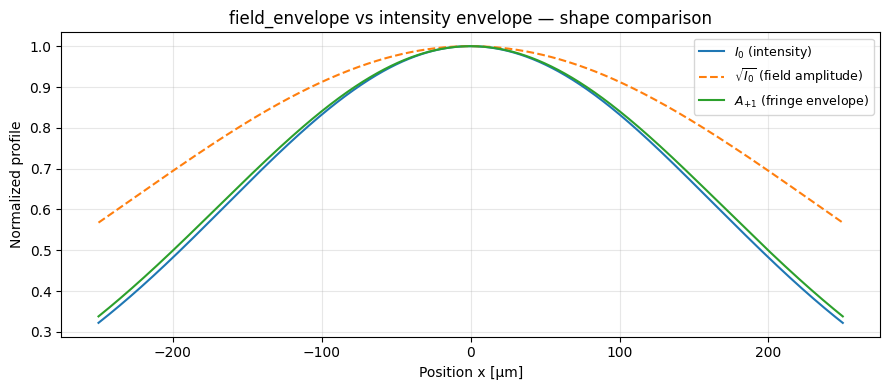

In [50]:
# Three quantities to compare:
#   I0       — intensity envelope a(x)              [intensity units]
#   A1       — fringe-envelope amplitude b/2        [intensity units]
#   √I0      — field amplitude, what 'field_envelope' mode returns
field_env = wfs.build_caustic_amplitude(env['I0'], env['A1'], mode='field_envelope')

# Normalize to peak = 1 for shape comparison
I0_n  = env['I0']  / env['I0'].max()
A1_n  = env['A1']  / env['A1'].max()
Fe_n  = field_env  / field_env.max()

# FWHM — robust to tails (counts only pixels above half-max)
def fwhm_of(profile, dx):
    """FWHM of a 1D profile, in same units as dx."""
    return np.sum(profile >= profile.max() / 2) * dx

fwhm_I0 = fwhm_of(env['I0'], dx_m)
fwhm_Fe = fwhm_of(field_env, dx_m)
fwhm_A1 = fwhm_of(env['A1'], dx_m)

# Second-moment σ — included as a secondary check (tail-sensitive; √ amplifies tails)
def sigma_2nd(F, x):
    F = np.clip(F, 0, None)
    s = F.sum()
    if s == 0: return np.nan
    mean = (x * F).sum() / s
    return np.sqrt(((x - mean)**2 * F).sum() / s)

sigma_I0 = sigma_2nd(env['I0'],  x_m)
sigma_Fe = sigma_2nd(field_env,  x_m)
sigma_A1 = sigma_2nd(env['A1'],  x_m)

V_peak = 2 * env['A1'].max() / env['I0'].max()

print("FWHM (robust):")
print(f"  FWHM(I0)         : {fwhm_I0*1e6:.2f} µm")
print(f"  FWHM(√I0)        : {fwhm_Fe*1e6:.2f} µm")
print(f"  FWHM(A1)         : {fwhm_A1*1e6:.2f} µm")
print(f"  FWHM(√I0)/FWHM(I0) : {fwhm_Fe/fwhm_I0:.4f}   (√2 ≈ 1.4142 for Gaussian core)")
print(f"  FWHM(A1)/FWHM(I0)  : {fwhm_A1/fwhm_I0:.4f}   (1.0000 with matched filters)")
print()
print("σ via 2nd-moment integral (tail-sensitive — see note):")
print(f"  σ(I0)            : {sigma_I0*1e6:.2f} µm")
print(f"  σ(√I0)           : {sigma_Fe*1e6:.2f} µm")
print(f"  σ(A1)            : {sigma_A1*1e6:.2f} µm")
print(f"  σ(√I0)/σ(I0)     : {sigma_Fe/sigma_I0:.4f}   (deviates from √2 due to tail amplification by √)")
print(f"  σ(A1)/σ(I0)      : {sigma_A1/sigma_I0:.4f}")
print()
print(f"Peak 2·A1/I0       : {V_peak:.4f}")
print(f"  Note: this is the harmonic ratio b₁/a₀, NOT the physical fringe visibility.")
print(f"  Ceiling depends on grating type. For an ideal binary 0/1 amplitude grating: 4/π ≈ 1.2732.")

# Overlay, central ±250 µm
half_w_disp = M // 8
disp        = slice(M//2 - half_w_disp, M//2 + half_w_disp)
x_disp_um   = x_m[disp] * 1e6

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_disp_um, I0_n[disp], lw=1.5, label='$I_0$ (intensity)')
ax.plot(x_disp_um, Fe_n[disp], lw=1.5, ls='--', label='$\\sqrt{I_0}$ (field amplitude)')
ax.plot(x_disp_um, A1_n[disp], lw=1.5, label='$A_{+1}$ (fringe envelope)')
ax.set_xlabel('Position x [µm]')
ax.set_ylabel('Normalized profile')
ax.set_title('field_envelope vs intensity envelope — shape comparison')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Apodizer FWHM (grating plane) : 60 µm
Peak V (raw)                  : 0.7354
Beam mask                     : 43642 px  (I0 > 2% of peak)


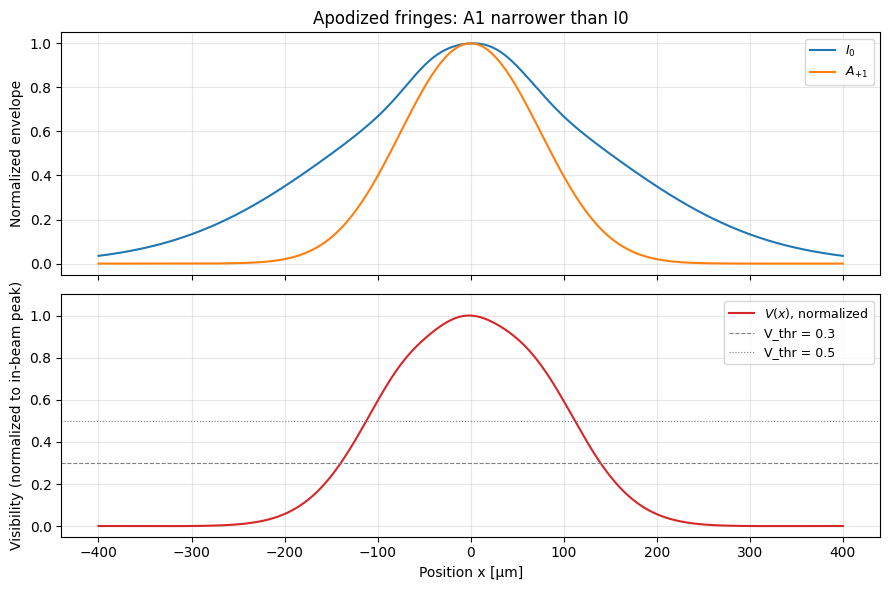

In [51]:
# Apodized grating: full modulation in a central window, no fringes outside.
# Construction:
#   g(x) = 0.5 + W_apod(x) · sign(sin(2π x/p)) / 2
# where W_apod(x) is a Gaussian window (1 at center, 0 in wings).
# Where W_apod = 1 → identical to original grating.
# Where W_apod = 0 → g = 0.5 (uniform half-transmission, no fringes).

apod_fwhm_m  = 60e-6                                              # in grating plane
apod_sigma_m = apod_fwhm_m / (2*np.sqrt(2*np.log(2)))
W_apod       = np.exp(-x_m**2 / (2*apod_sigma_m**2))

grating_pattern_apod = 0.5 + W_apod * np.sign(np.sin(2*np.pi * x_m / grating_pitch_m)) / 2

# Re-run the propagation chain with the apodized grating
E_modulated_apod = E_at_grating * grating_pattern_apod
E_at_z_T_apod    = propTF(E_modulated_apod, L_m, wavelength_m, z_T_m)
I_at_z_T_apod    = np.abs(E_at_z_T_apod)**2

# Push through the front of the wfs pipeline
img_apod      = np.tile(I_at_z_T_apod[None, :], (n_rows, 1))
profile_apod  = wfs.extract_profile(img_apod, y_roi, axis=axis)
carrier_apod  = wfs.find_carrier(profile_apod, dx_m, grating_pitch_m, band_factor=1.5)
env_apod      = wfs.extract_envelopes(carrier_apod['fft_avg'], carrier_apod['freq'],
                                      carrier_apod['k_peak'],
                                      sigma_ratio_0=5, sigma_ratio_1=10)

# Visibility V(x) = 2·A1 / I0, with the same I0_threshold guard as build_caustic_amplitude
I0_apod = env_apod['I0']
A1_apod = env_apod['A1']

I0_threshold = 0.02
beam_mask    = I0_apod > I0_threshold * I0_apod.max()
V            = np.zeros_like(I0_apod)
V[beam_mask] = 2 * A1_apod[beam_mask] / I0_apod[beam_mask]
V_peak_inbeam = V[beam_mask].max() if beam_mask.any() else 0.0
V_norm        = V / V_peak_inbeam if V_peak_inbeam > 0 else V

print(f"Apodizer FWHM (grating plane) : {apod_fwhm_m*1e6:.0f} µm")
print(f"Peak V (raw)                  : {V_peak_inbeam:.4f}")
print(f"Beam mask                     : {beam_mask.sum()} px  "
      f"(I0 > {I0_threshold:.0%} of peak)")

# Two-panel plot: envelopes + visibility, central ±400 µm
half_w_disp = int(400e-6 / dx_m)
disp        = slice(M//2 - half_w_disp, M//2 + half_w_disp)
x_disp_um   = x_m[disp] * 1e6

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(x_disp_um, I0_apod[disp] / I0_apod.max(), lw=1.5, label='$I_0$')
axes[0].plot(x_disp_um, A1_apod[disp] / A1_apod.max(), lw=1.5, label='$A_{+1}$')
axes[0].set_ylabel('Normalized envelope')
axes[0].set_title('Apodized fringes: A1 narrower than I0')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_disp_um, V_norm[disp], lw=1.5, color='C3', label='$V(x)$, normalized')
for V_thr, ls in zip([0.3, 0.5], ['--', ':']):
    axes[1].axhline(V_thr, color='gray', lw=0.8, ls=ls, label=f'V_thr = {V_thr}')
axes[1].set_xlabel('Position x [µm]')
axes[1].set_ylabel('Visibility (normalized to in-beam peak)')
axes[1].set_ylim(-0.05, 1.1)
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

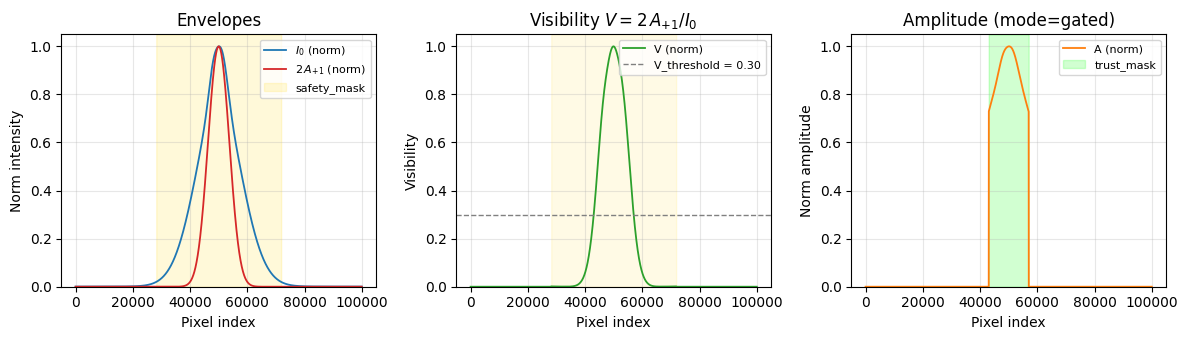

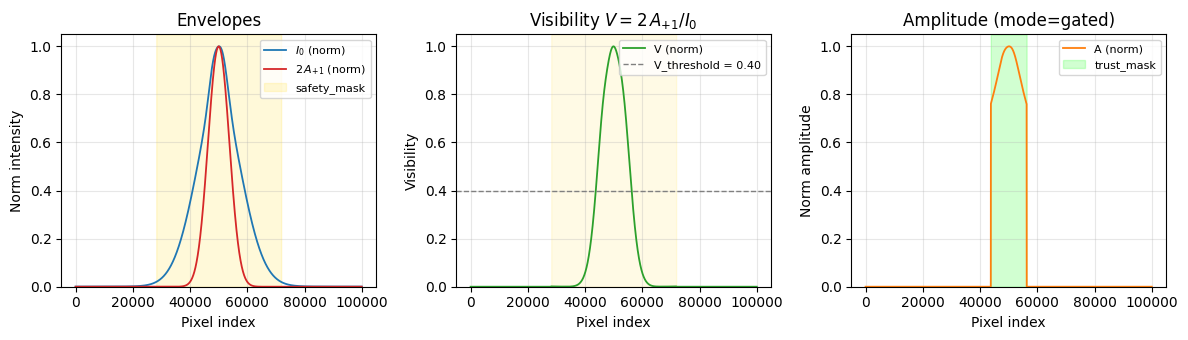

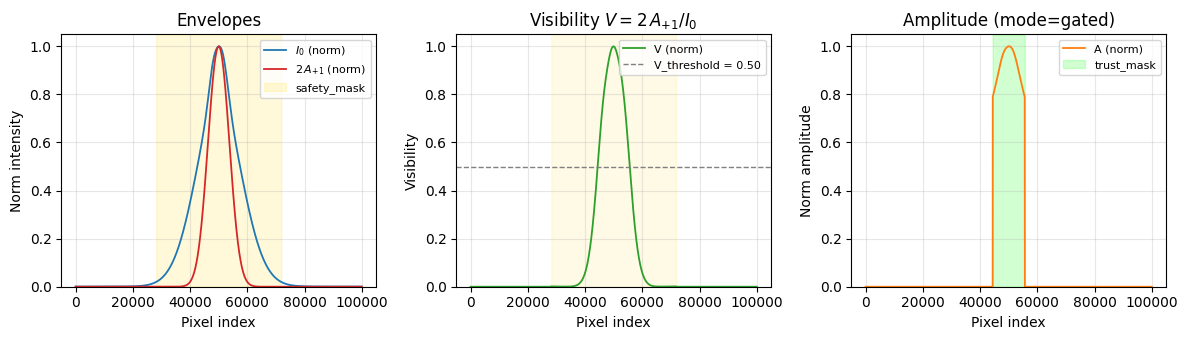

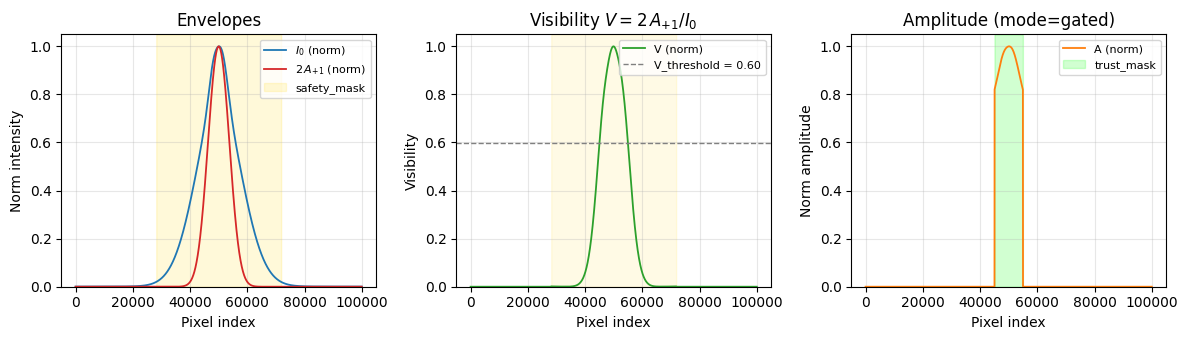

V_threshold sweep (apodized frame):
   V_thr    trust-region width      A peak
    0.30              279.1 µm      0.0791
    0.40              250.3 µm      0.0791
    0.50              224.2 µm      0.0791
    0.60              198.5 µm      0.0791


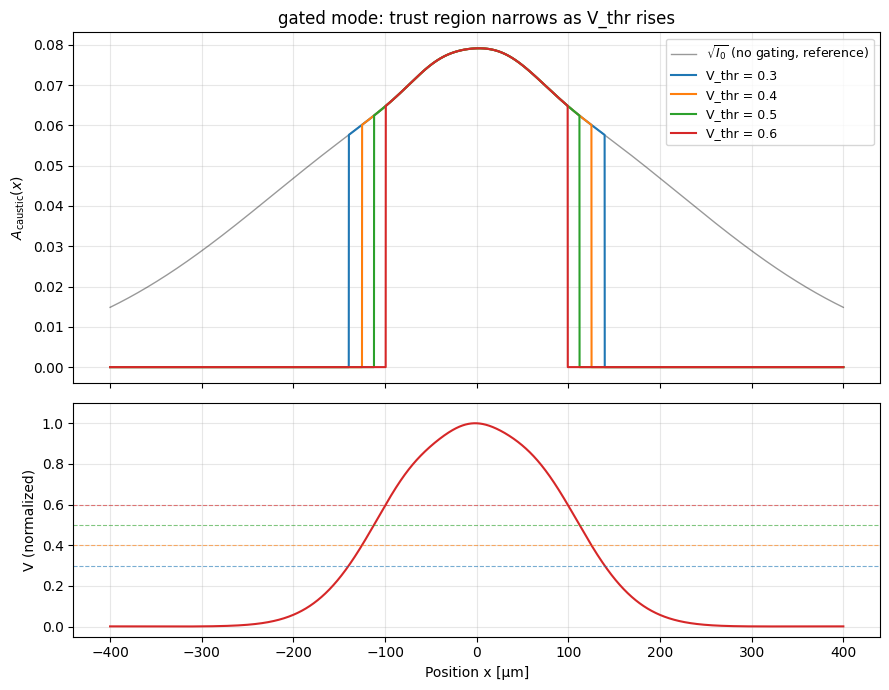

In [52]:
# Sweep V_threshold on the apodized frame from A18 (where fringes don't fill the beam)
V_thrs = [0.3, 0.4, 0.5, 0.6]

# Compute A_caustic for each threshold
A_caustics = {V_thr: wfs.build_caustic_amplitude(I0_apod, A1_apod,
                                                  mode='gated', V_threshold=V_thr)
              for V_thr in V_thrs}

# Trust-region width per threshold (count of nonzero pixels × dx)
print(f"V_threshold sweep (apodized frame):")
print(f"  {'V_thr':>6}  {'trust-region width':>20}  {'A peak':>10}")
for V_thr in V_thrs:
    A      = A_caustics[V_thr]
    n_trust = int((A > 0).sum())
    width   = n_trust * dx_m * 1e6
    print(f"  {V_thr:>6.2f}  {width:>17.1f} µm  {A.max():>10.4f}")

# Plot A_caustic for each threshold, plus √I0 (no gating) as reference
half_w_disp = int(400e-6 / dx_m)
disp        = slice(M//2 - half_w_disp, M//2 + half_w_disp)
x_disp_um   = x_m[disp] * 1e6
field_env_apod = np.sqrt(np.clip(I0_apod, 0, None))

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                         gridspec_kw={'height_ratios': [1.5, 1]})

# Top: A_caustic for each threshold
axes[0].plot(x_disp_um, field_env_apod[disp], lw=1.0, color='k', alpha=0.4,
             label='$\\sqrt{I_0}$ (no gating, reference)')
for V_thr, color in zip(V_thrs, ['C0', 'C1', 'C2', 'C3']):
    axes[0].plot(x_disp_um, A_caustics[V_thr][disp], lw=1.5, color=color,
                 label=f'V_thr = {V_thr}')
axes[0].set_ylabel('$A_\\mathrm{caustic}(x)$')
axes[0].set_title('gated mode: trust region narrows as V_thr rises')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].grid(True, alpha=0.3)

# Bottom: V(x) with all thresholds marked
axes[1].plot(x_disp_um, V_norm[disp], lw=1.5, color='C3', label='V(x), normalized')
for V_thr, color in zip(V_thrs, ['C0', 'C1', 'C2', 'C3']):
    axes[1].axhline(V_thr, color=color, lw=0.8, ls='--', alpha=0.6)
axes[1].set_xlabel('Position x [µm]')
axes[1].set_ylabel('V (normalized)')
axes[1].set_ylim(-0.05, 1.1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Wing inspection — natural I0 dynamic range on apodized frame:
  I0 peak    : 6.261e-03
  I0 wing min: 4.030e-06
  Dynamic range: 1.6e+03

I0_threshold sweep (mode='gated', V_threshold=0.4):
    I0_thr    beam_mask px    trust px   A finite?       A max


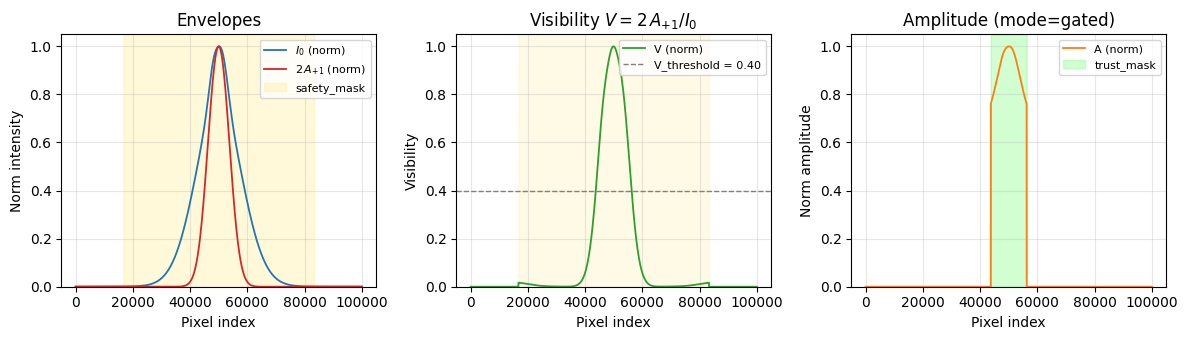

     0.001           66570       12516        True      0.0791


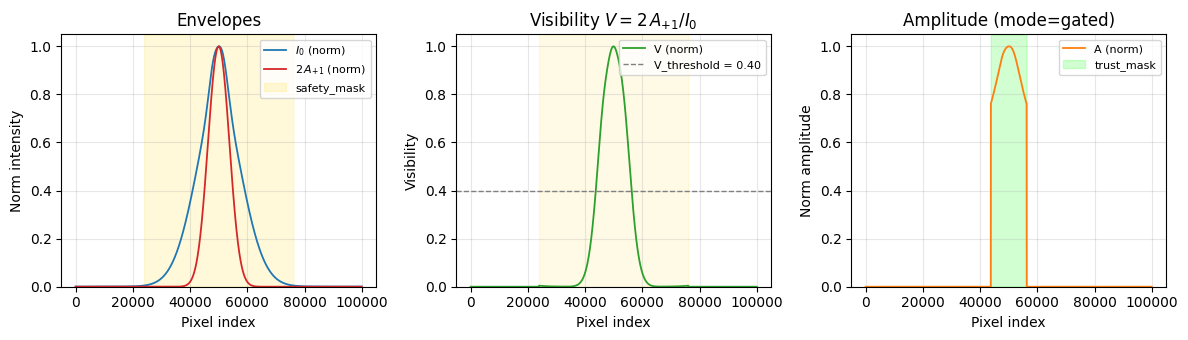

     0.005           52122       12516        True      0.0791


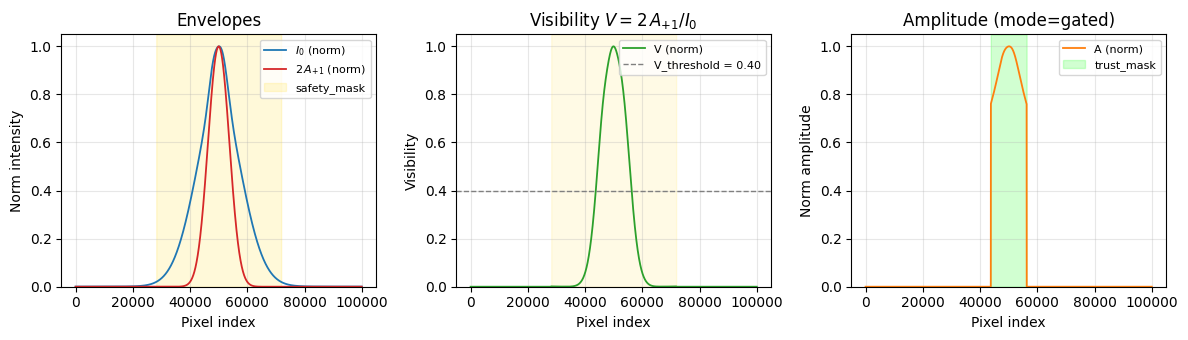

     0.020           43642       12516        True      0.0791


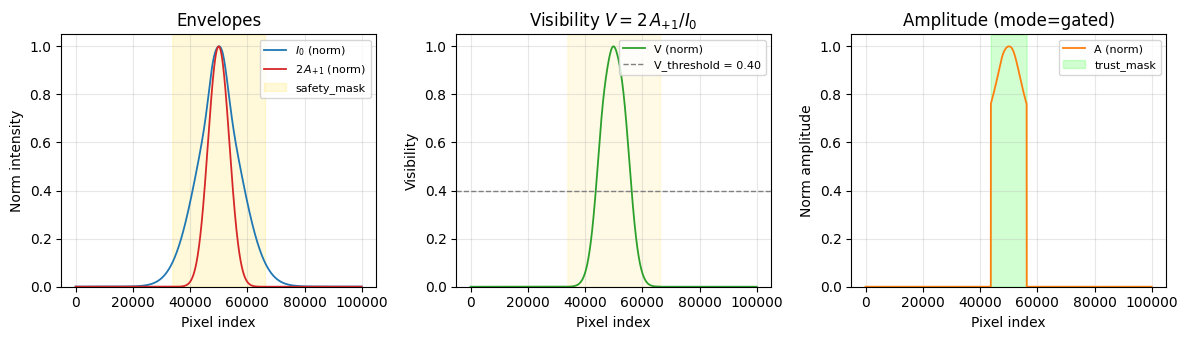

     0.100           32382       12516        True      0.0791


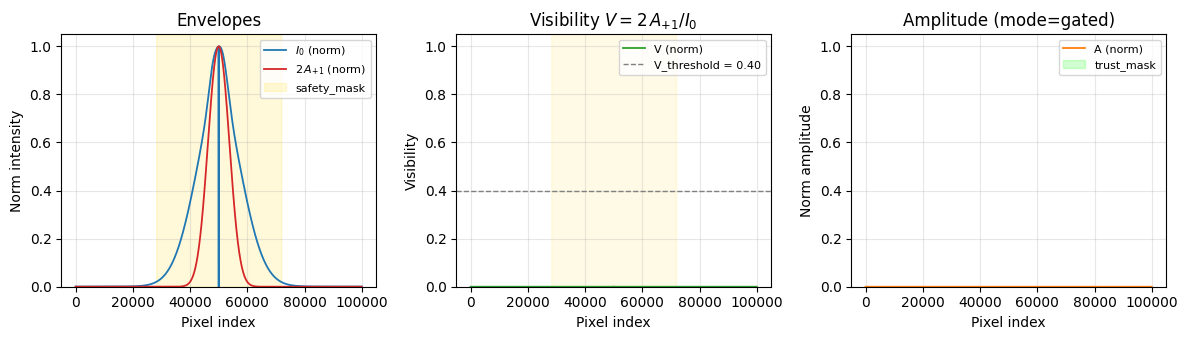


Hard-zero hole test (200 px of I0 = 0 at beam center):
  A finite?       : True
  A in hole (max) : 0.0000e+00   (should be 0)
  A outside hole  : 0.0000
  field_envelope mode, A in hole (max): 0.0000e+00   (should be 0 since √0 = 0)


In [53]:
# Use the apodized frame (already has the natural dark wings we want to stress-test)
print("Wing inspection — natural I0 dynamic range on apodized frame:")
print(f"  I0 peak    : {I0_apod.max():.3e}")
print(f"  I0 wing min: {I0_apod.min():.3e}")
print(f"  Dynamic range: {I0_apod.max() / max(I0_apod.min(), 1e-30):.1e}")

# I0_threshold sweep — fraction of peak below which V is not computed
I0_thrs = [0.001, 0.005, 0.02, 0.1]   # 0.02 is the default
V_thr   = 0.4

print(f"\nI0_threshold sweep (mode='gated', V_threshold={V_thr}):")
print(f"  {'I0_thr':>8}  {'beam_mask px':>14}  {'trust px':>10}  "
      f"{'A finite?':>10}  {'A max':>10}")
for I0_thr in I0_thrs:
    A = wfs.build_caustic_amplitude(I0_apod, A1_apod,
                                    mode='gated',
                                    V_threshold=V_thr,
                                    I0_threshold=I0_thr)
    beam_mask_local = I0_apod > I0_thr * I0_apod.max()
    n_beam   = int(beam_mask_local.sum())
    n_trust  = int((A > 0).sum())
    A_finite = np.all(np.isfinite(A))
    print(f"  {I0_thr:>8.3f}  {n_beam:>14d}  {n_trust:>10d}  "
          f"{str(A_finite):>10}  {A.max():>10.4f}")

# Explicit destructive test: force a hard-zero hole in I0 and verify no crash
I0_with_hole         = I0_apod.copy()
hole_slice           = slice(M//2 - 100, M//2 + 100)   # 200 px hole at the beam peak
I0_with_hole[hole_slice] = 0.0

A_hole = wfs.build_caustic_amplitude(I0_with_hole, A1_apod,
                                     mode='gated', V_threshold=0.4, I0_threshold=0.02)

print(f"\nHard-zero hole test (200 px of I0 = 0 at beam center):")
print(f"  A finite?       : {np.all(np.isfinite(A_hole))}")
print(f"  A in hole (max) : {A_hole[hole_slice].max():.4e}   (should be 0)")
print(f"  A outside hole  : {A_hole[~np.isin(np.arange(M), np.arange(hole_slice.start, hole_slice.stop))].max():.4f}")

# Also test field_envelope mode on the same hole — should pass through (no V computation)
A_hole_fe = wfs.build_caustic_amplitude(I0_with_hole, A1_apod, mode='field_envelope')
print(f"  field_envelope mode, A in hole (max): {A_hole_fe[hole_slice].max():.4e}   "
      f"(should be 0 since √0 = 0)")

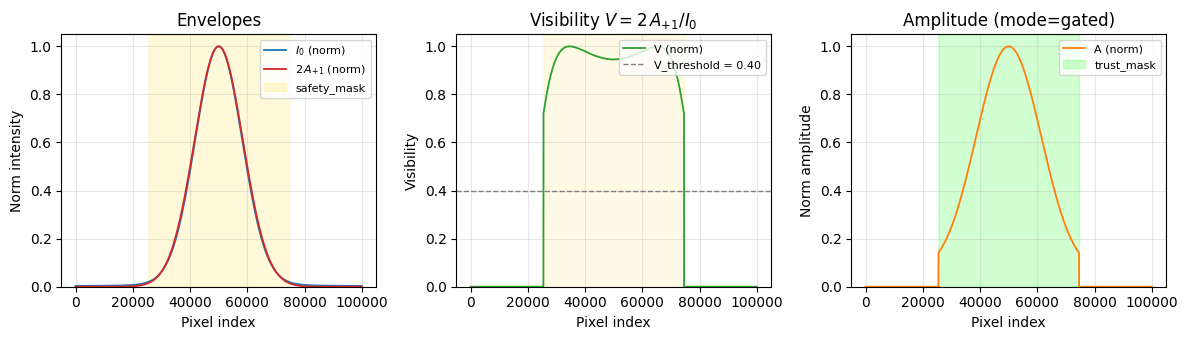

Trust region : 49124 px  (982 µm wide)
Inside trust : max |A_field - A_gated| = 0.0000e+00  (expected 0)
Outside trust: max A_field = 0.0133  (this is the 'amplitude thrown away by gating')
Field amplitude integral: inside trust = 5.3998e-05, outside = 7.2559e-06  (outside is 11.8% of total)


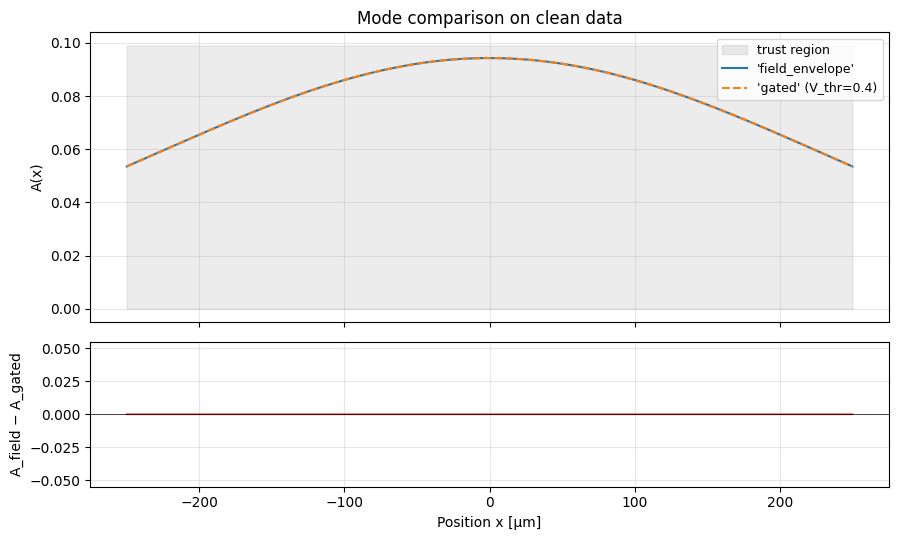

In [54]:
# Compare both modes on the clean Stage A frame (env from A9, not env_apod)
A_field = wfs.build_caustic_amplitude(env['I0'], env['A1'], mode='field_envelope')
A_gated = wfs.build_caustic_amplitude(env['I0'], env['A1'],
                                       mode='gated', V_threshold=0.4)

# Compute V(x) for the clean frame, peak-normalized (mirrors A18 logic)
I0_clean = env['I0']
A1_clean = env['A1']
beam_mask_clean = I0_clean > 0.02 * I0_clean.max()
V_clean = np.zeros_like(I0_clean)
V_clean[beam_mask_clean] = 2 * A1_clean[beam_mask_clean] / I0_clean[beam_mask_clean]
V_peak_clean = V_clean[beam_mask_clean].max() if beam_mask_clean.any() else 1.0
V_clean_norm = V_clean / V_peak_clean

trust_mask = wfs.fill_mask_gaps(V_clean_norm > 0.4)

# Diff inside vs outside trust region
diff = A_field - A_gated

print(f"Trust region : {trust_mask.sum()} px  "
      f"({trust_mask.sum() * dx_m * 1e6:.0f} µm wide)")
print(f"Inside trust : max |A_field - A_gated| = {np.abs(diff[trust_mask]).max():.4e}  "
      f"(expected 0)")
print(f"Outside trust: max A_field = {A_field[~trust_mask].max():.4f}  "
      f"(this is the 'amplitude thrown away by gating')")

# Integrated amplitude inside vs outside trust
int_in  = A_field[trust_mask].sum() * dx_m
int_out = A_field[~trust_mask].sum() * dx_m
print(f"Field amplitude integral: "
      f"inside trust = {int_in:.4e}, outside = {int_out:.4e}  "
      f"(outside is {int_out/(int_in+int_out)*100:.1f}% of total)")

# Plot: overlay both modes, trust region shaded; difference below
half_w_disp = M // 8
disp        = slice(M//2 - half_w_disp, M//2 + half_w_disp)
x_disp_um   = x_m[disp] * 1e6
trust_disp  = trust_mask[disp]

fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})

axes[0].fill_between(x_disp_um, 0, A_field[disp].max()*1.05,
                     where=trust_disp, color='gray', alpha=0.15, label='trust region')
axes[0].plot(x_disp_um, A_field[disp], lw=1.5, label="'field_envelope'")
axes[0].plot(x_disp_um, A_gated[disp], lw=1.5, ls='--', label="'gated' (V_thr=0.4)")
axes[0].set_ylabel('A(x)')
axes[0].set_title('Mode comparison on clean data')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_disp_um, diff[disp], lw=1.2, color='C3')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('Position x [µm]')
axes[1].set_ylabel('A_field − A_gated')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

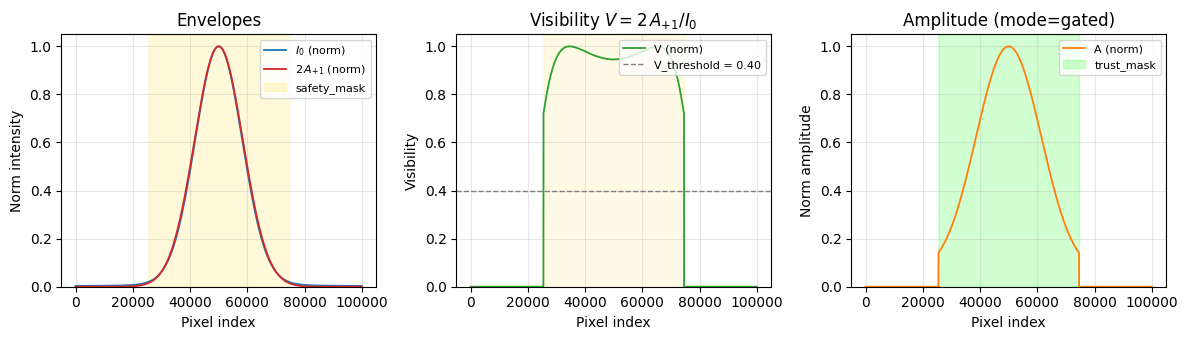

debug keys: ['A', 'V', 'safety_mask', 'trust_mask', 'mode_used', 'I0', 'A1', 'V_threshold']
trust_mask covers 12516 / 100000 px (12.5%)


In [55]:
# Demo: plot=True default behavior + debug=True return
# field_envelope: no plot by default
_ = wfs.build_caustic_amplitude(env['I0'], env['A1'], mode='field_envelope')

# gated: plots automatically by default
_ = wfs.build_caustic_amplitude(env['I0'], env['A1'], mode='gated', V_threshold=0.4)

# debug=True returns a dict; you can re-plot or inspect later
dbg = wfs.build_caustic_amplitude(env_apod['I0'], env_apod['A1'],
                                  mode='gated', V_threshold=0.4,
                                  debug=True, plot=False)
print('debug keys:', list(dbg.keys()))
print(f"trust_mask covers {dbg['trust_mask'].sum()} / {len(dbg['A'])} px "
      f"({100*dbg['trust_mask'].mean():.1f}%)")

In [56]:
# Run full pipeline with caustic_amplitude='field_envelope', confirm new wiring
result_fe = wfs.reconstruct_single(
    img_synth, dx_m, grating_pitch_m, wavelength_m, z_T_m,
    y_roi=y_roi, axis=axis,
    propagate=True,
    z_range_m=z_range_m,                   # reuse A14's scan
    caustic_amplitude='field_envelope',
    verbose=True,
)

print("\n--- Integration checks ('field_envelope' mode) ---")
print(f"'A_caustic' in result   : {'A_caustic' in result_fe}")
print(f"'caustic_mode' in result: {'caustic_mode' in result_fe}")
print(f"result['caustic_mode']  : {result_fe['caustic_mode']}")

# Compare A_caustic from full pipeline vs standalone call
A_standalone = wfs.build_caustic_amplitude(result_fe['I0'], result_fe['A1'],
                                            mode='field_envelope')
diff_A = np.abs(result_fe['A_caustic'] - A_standalone).max()
print(f"|A_caustic - standalone|: {diff_A:.4e}  (expected 0)")

# Cross-check focus against our A14 standalone run
print(f"\nz_focus  : {result_fe['z_focus']:+.4f} m  "
      f"(A14 standalone: {prop['z_focus']:+.4f} m)")
print(f"σ_focus  : {result_fe['sigma_focus']*1e6:.3f} µm  "
      f"(A14 standalone: {prop['sigma_focus']*1e6:.3f} µm)")

# Same test for gated mode
print("\n--- Integration checks ('gated' mode) ---")
result_g = wfs.reconstruct_single(
    img_synth, dx_m, grating_pitch_m, wavelength_m, z_T_m,
    y_roi=y_roi, axis=axis,
    propagate=True,
    z_range_m=z_range_m,
    caustic_amplitude='gated', V_threshold=0.4,
    verbose=True,
)
print(f"result['caustic_mode']  : {result_g['caustic_mode']}")
print(f"z_focus (gated)         : {result_g['z_focus']:+.4f} m")
print(f"σ_focus (gated)         : {result_g['sigma_focus']*1e6:.3f} µm")
print(f"Δσ vs field_envelope    : {(result_g['sigma_focus'] - result_fe['sigma_focus'])*1e6:+.3f} µm")

[good]  λ=2.48nm  k_peak=26.5 cyc/mm  r_DC=1.8  SNR=4527.4  f_pred=-2.43m  RMS_W=6.9nm  RMS_resid=0.000nm  z_focus=-2.42m(fwhm_min)  RMS@focus=0.029nm

--- Integration checks ('field_envelope' mode) ---
'A_caustic' in result   : True
'caustic_mode' in result: True
result['caustic_mode']  : field_envelope
|A_caustic - standalone|: 0.0000e+00  (expected 0)

z_focus  : -2.4200 m  (A14 standalone: -2.4200 m)
σ_focus  : 4.551 µm  (A14 standalone: 4.551 µm)

--- Integration checks ('gated' mode) ---
[good]  λ=2.48nm  k_peak=26.5 cyc/mm  r_DC=1.8  SNR=4527.4  f_pred=-2.43m  RMS_W=6.9nm  RMS_resid=0.000nm  z_focus=-2.42m(fwhm_min)  RMS@focus=0.011nm
result['caustic_mode']  : gated
z_focus (gated)         : -2.4200 m
σ_focus (gated)         : 6.977 µm
Δσ vs field_envelope    : +2.425 µm


In [57]:
# A-verify-1: PASS/FAIL assertions on the new fit_mask wiring
#
# Baselines: record on first run after the refactor; rerun should match.
# Tolerances are loose by design — synthetic data is deterministic, so
# any drift above these levels indicates a real change.

# Run-once baselines (auto-populate on first run; replace with literals
# after first execution if you want them to survive kernel restarts).
BASELINE_F_PRED_M       = result_fe['f_pred']
BASELINE_RMS_RESID_NM   = result_fe['rms_resid_nm']
BASELINE_Z_FOCUS_M      = result_fe['z_focus']
BASELINE_SIGMA_FOCUS_UM = result_fe['sigma_focus'] * 1e6

# --- 1. New result keys present ---
required_keys = ['V', 'trust_mask', 'safety_mask', 'fit_mask', 'n_fit_px']
missing = [k for k in required_keys if k not in result_fe]
keys_ok = not missing

# --- 2. fit_mask ⊆ beam_mask, and they nearly match on clean synthetic ---
fm = result_fe['fit_mask']
bm = result_fe['beam_mask']
subset_ok = bool((fm & ~bm).sum() == 0)
ratio = result_fe['n_fit_px'] / result_fe['n_mask_px']
coverage_ok = ratio >= 0.98

# --- 3. f_pred and rms_resid stable ---
f_pred_ok    = abs(result_fe['f_pred'] - BASELINE_F_PRED_M) < 1e-6
rms_resid_ok = abs(result_fe['rms_resid_nm'] - BASELINE_RMS_RESID_NM) \
               / max(BASELINE_RMS_RESID_NM, 1e-6) < 0.01

# --- 4. trust_mask matches the standalone build_caustic_amplitude path ---
dbg = wfs.build_caustic_amplitude(result_fe['I0'], result_fe['A1'],
                                   mode='gated',
                                   V_threshold=result_fe['V_threshold'],
                                   debug=True, plot=False)
helper_consistent = bool(np.array_equal(dbg['trust_mask'], result_fe['trust_mask'])) \
                    and bool(np.allclose(dbg['V'], result_fe['V']))

# --- 5. Focus locator is 'fwhm_min' and focus not at edge (sanity checks) ---
locator_ok      = result_fe['z_focus_locator'] == 'fwhm_min'
no_edge_warning = not result_fe['focus_at_edge']

# --- Report ---
checks = [
    ('new result keys present',           keys_ok,           f"missing={missing}" if missing else "ok"),
    ('fit_mask ⊆ beam_mask',              subset_ok,         f"{(fm & ~bm).sum()} stray px"),
    ('n_fit_px / n_mask_px ≥ 0.98',       coverage_ok,       f"ratio={ratio:.4f}"),
    ('f_pred stable',                     f_pred_ok,         f"f_pred={result_fe['f_pred']:+.6f} m"),
    ('rms_resid stable (<1% drift)',      rms_resid_ok,      f"rms_resid={result_fe['rms_resid_nm']:.4f} nm"),
    ('helper ↔ pipeline V/trust_mask',    helper_consistent, "ok"),
    ('z_focus_locator = fwhm_min',         locator_ok,        f"got {result_fe['z_focus_locator']!r}"),
    ('focus_at_edge = False',              no_edge_warning,   f"edge={result_fe['focus_at_edge']}"),
]

print(f"\n{'='*60}")
print("A-verify-1: Stage A regression checks")
print(f"{'='*60}")
for name, ok, detail in checks:
    tag = 'PASS' if ok else 'FAIL'
    print(f"  [{tag}] {name:<35} {detail}")
all_pass = all(ok for _, ok, _ in checks)
print(f"\n  Overall: {'PASS' if all_pass else 'FAIL'}")
print(f"{'='*60}\n")


A-verify-1: Stage A regression checks
  [PASS] new result keys present             ok
  [PASS] fit_mask ⊆ beam_mask                0 stray px
  [PASS] n_fit_px / n_mask_px ≥ 0.98         ratio=1.0000
  [PASS] f_pred stable                       f_pred=-2.426396 m
  [PASS] rms_resid stable (<1% drift)        rms_resid=0.0001 nm
  [PASS] helper ↔ pipeline V/trust_mask      ok
  [PASS] z_focus_locator = fwhm_min          got 'fwhm_min'
  [PASS] focus_at_edge = False               edge=False

  Overall: PASS



In [58]:
# Stage A summary: both modes, with ground-truth deviations
z_focus_GT     = -(z_to_grating_m + z_T_m)
sigma_focus_GT = source_sigma_m

print(f"{'='*72}")
print(f"Stage A — synthetic interferogram, focus reconstruction summary")
print(f"{'='*72}")
print(f"\nGround truth (sim geometry):")
print(f"  z_focus_GT      : {z_focus_GT:+.4f} m")
print(f"  σ_focus_GT      : {sigma_focus_GT*1e6:.3f} µm  (intensity σ at source waist)")

print(f"\n{'mode':<18} {'z_focus [m]':>14} {'Δz [mm]':>10} "
      f"{'σ_focus [µm]':>14} {'Δσ [µm]':>10}")
print(f"{'-'*72}")
for label, res in [('field_envelope', result_fe), ('gated (V_thr=0.4)', result_g)]:
    dz_mm = (res['z_focus']     - z_focus_GT)     * 1e3
    ds_um = (res['sigma_focus'] - sigma_focus_GT) * 1e6
    print(f"{label:<18} {res['z_focus']:>+14.4f} {dz_mm:>+10.1f} "
          f"{res['sigma_focus']*1e6:>14.3f} {ds_um:>+10.3f}")

print(f"\nNotes:")
print(f"  • z_focus matches GT to within the 10 mm scan step in both modes.")
print(f"  • field_envelope σ overshoots GT by ~6% — under investigation (to-do #7).")
print(f"  • gated mode adds ~55% σ broadening from hard-edge diffraction;")
print(f"    on clean data this is pure cost, field_envelope wins.")
print(f"  • On real data with low-V regions, the tradeoff can flip.")

Stage A — synthetic interferogram, focus reconstruction summary

Ground truth (sim geometry):
  z_focus_GT      : -2.4000 m
  σ_focus_GT      : 4.247 µm  (intensity σ at source waist)

mode                  z_focus [m]    Δz [mm]   σ_focus [µm]    Δσ [µm]
------------------------------------------------------------------------
field_envelope            -2.4200      -20.0          4.551     +0.305
gated (V_thr=0.4)         -2.4200      -20.0          6.977     +2.730

Notes:
  • z_focus matches GT to within the 10 mm scan step in both modes.
  • field_envelope σ overshoots GT by ~6% — under investigation (to-do #7).
  • gated mode adds ~55% σ broadening from hard-edge diffraction;
    on clean data this is pure cost, field_envelope wins.
  • On real data with low-V regions, the tradeoff can flip.


# TEST, with Real Data


## Access Data from Local Files

Example interferogram files from COSMIC beamline measurements (May 2021):

- `WFS210515-0002-025.tif` — [Drive](https://drive.google.com/drive/folders/1wlIfJejeOJJOoCX6qqIchdNpvPdQuazu)
- `WFS210517-0014` series — [Drive](https://drive.google.com/drive/folders/1w0XgUvzdo5vBcAhhNNgx4M3P2I-l562r)
- `WFS210515-0089` series — [Drive](https://drive.google.com/drive/folders/1wlIfJejeOJJOoCX6qqIchdNpvPdQuazu)

For experimental details, see the [logbooks](https://drive.google.com/drive/folders/1WpgDFEo74Cp3HBMqQwpEPwvhJowtZiwU) by Antoine. 

Loaded: WFS210515-0002-025.tif
Image shape: (3008, 4112) (height*width), dtype: uint16
Intensity range: [0, 4092]


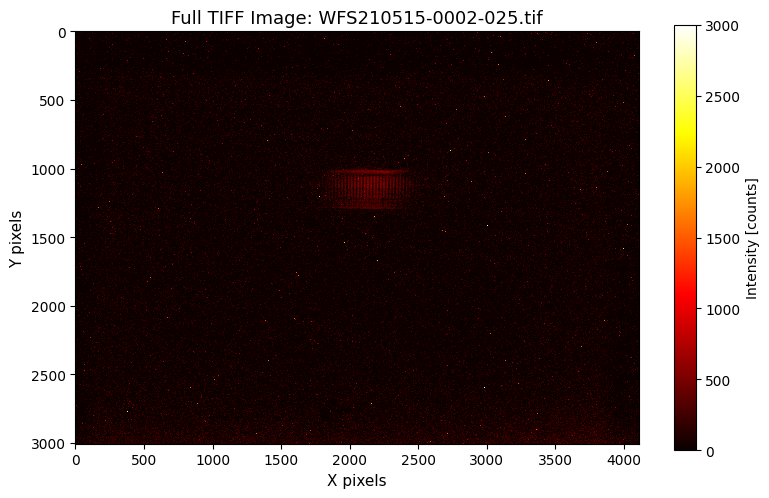

In [69]:
# Load TIFF Image
filename = "WFS210515-0002-025.tif"
im = Image.open(f'{filename}')
image = np.array(im) 

print(f"Loaded: {filename}")
print(f"Image shape: {image.shape} (height*width), dtype: {image.dtype}")
print(f"Intensity range: [{image.min()}, {image.max()}]")

# Visualize full image
plt.figure(figsize=(8, 5))
plt.imshow(image, cmap='hot', interpolation='nearest', vmax=3000)
plt.title(f'Full TIFF Image: {filename}', fontsize=13)
plt.xlabel('X pixels', fontsize=11)
plt.ylabel('Y pixels', fontsize=11)
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

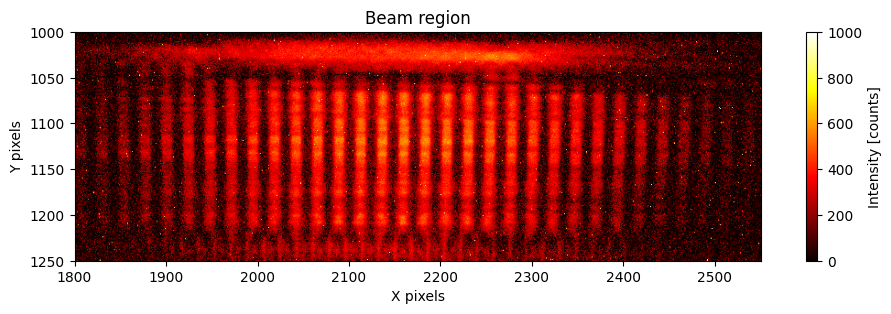

In [70]:
plt.figure(figsize=(10, 3))
plt.imshow(image[1000:1250, 1800:2550], cmap='hot', vmax=1000,
           extent=(1800, 2550, 1250, 1000))
plt.title('Beam region')
plt.xlabel('X pixels'); plt.ylabel('Y pixels')
plt.colorbar(label='Intensity [counts]')
plt.tight_layout(); plt.show()

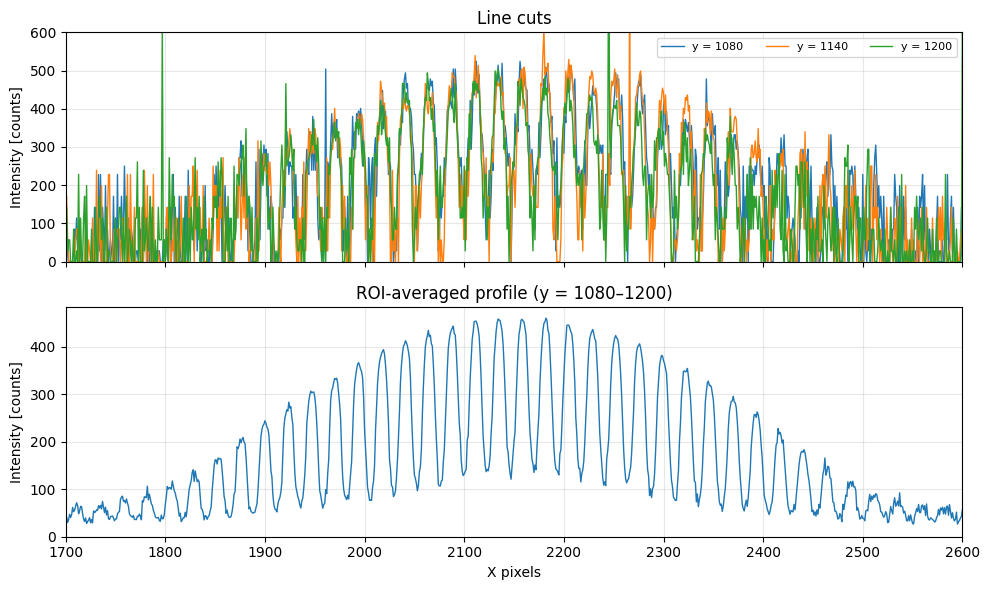

In [71]:
y_cuts = [1080, 1140, 1200]
y_roi = (1080, 1200)         # fringe band for averaging

fig, (ax_cut, ax_roi) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# --- Top: individual line cuts ---
for yc in y_cuts:
    ax_cut.plot(image[yc, :], lw=1, label=f'y = {yc}')

ax_cut.set_ylabel('Intensity [counts]')
ax_cut.set_xlim(1700, 2600)
ax_cut.set_ylim(0, 600)
ax_cut.set_title('Line cuts')
ax_cut.legend(ncol=3, fontsize=8)
ax_cut.grid(alpha=0.3)

# --- Bottom: ROI-averaged profile vs X pixels ---
roi = image[y_roi[0]:y_roi[1], :]        # rows in band, all columns
line_profile = np.mean(roi, axis=0)      # average over y → 1D vs x
x_pix = np.arange(len(line_profile))     # X pixel index

ax_roi.plot(x_pix, line_profile, lw=1)
ax_roi.set_xlabel('X pixels')
ax_roi.set_ylabel('Intensity [counts]')
ax_roi.set_ylim(bottom=0)
ax_roi.set_title(f'ROI-averaged profile (y = {y_roi[0]}–{y_roi[1]})')
ax_roi.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [72]:
# Physical Parameters (Experimental Setup)

camera_pixel_m = 3.45e-6      # Camera pixel size [m]
magnification = 2.85          # Objective magnification (Boli optics)
dx_m = camera_pixel_m / magnification  # Effective pixel size [m]

energy_eV = 607               # Photon energy [eV]
wavelength_m = 1.23984e-6 / energy_eV

# Grating
grating_pitch_m = 22e-6       # Shearing grating pitch [m]

# Propagation distances
z_gd_m = 0.4                  # Distance from grating to detector [m]

## Reconstruction


[good]  λ=2.04nm  k_peak=35.2 cyc/mm  r_DC=5.4  SNR=130.7  f_pred=-1.76m  RMS_W=343.5nm  RMS_resid=0.036nm  z_focus=-1.76m(fwhm_min)  RMS@focus=0.061nm


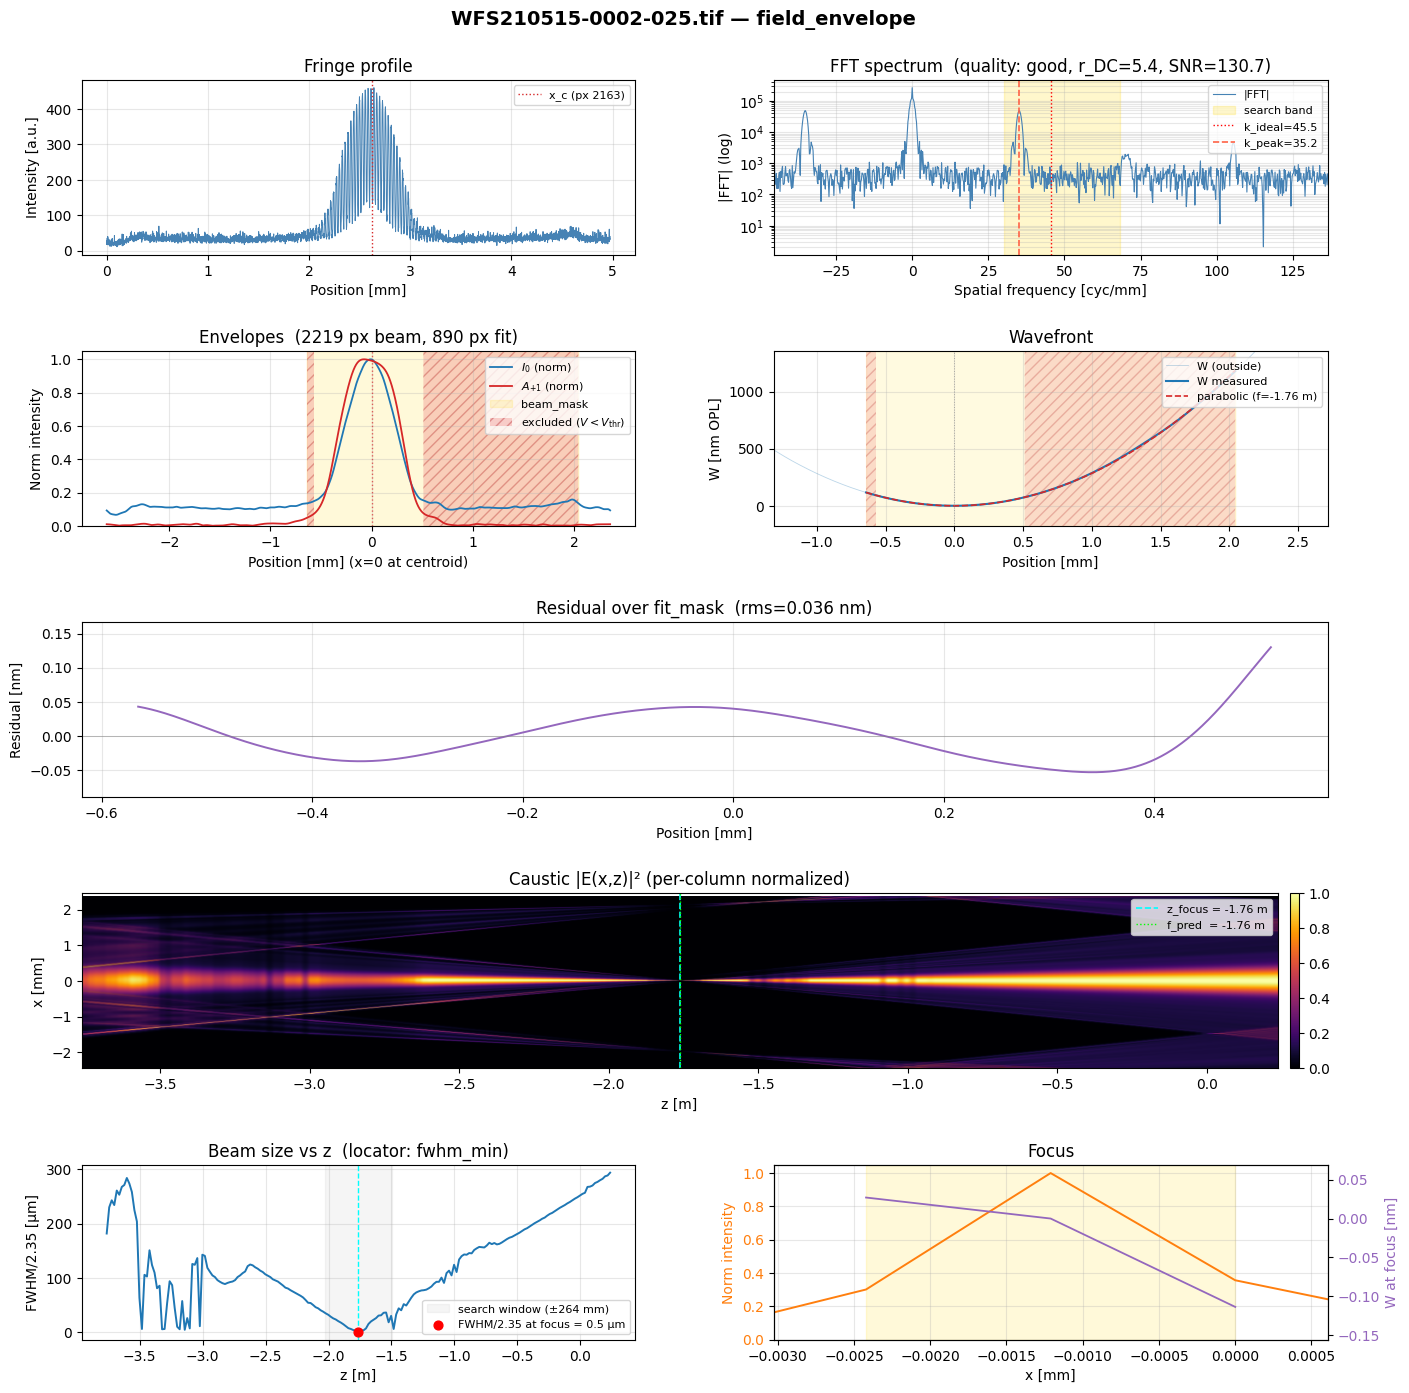


quality flag : good  (r_DC = 5.42, SNR = 130.7)
k_peak/k_ideal: 0.7735
f_pred        : -1.762 m
rms_resid     : 0.036 nm
pv_resid      : 0.183 nm
z_focus       : -1.762 m  (from caustic)
sigma_focus   : 923.48 µm

--- Item A: fit_mask decoupling effect ---
  rms_resid (old, beam_mask as fit domain): 2.479 nm
  rms_resid (new, fit_mask = beam ∩ trust): 0.036 nm
  improvement factor                      : 69.2×
  n_mask_px (beam_mask)                   : 2219
  n_fit_px  (fit_mask)                    : 890
  fit/beam coverage                       : 40.1%
  pixels excluded (rejected hump)         : 1329


In [73]:
# Stage B — first reconstruction on real data (field_envelope mode)
y_roi = slice(1080, 1200)    # picked from the beam-region zoom

result = wfs.quick_look(
    image, dx_m, grating_pitch_m, wavelength_m, z_gd_m,
    y_roi=y_roi, axis=0,
    propagate=True,
    caustic_amplitude='field_envelope',
    title=f'{filename} — field_envelope',
)

# Pass-criterion summary
print()
print(f"quality flag : {result['quality']}  "
      f"(r_DC = {result['dc_carrier_ratio']:.2f}, SNR = {result['carrier_snr']:.1f})")
print(f"k_peak/k_ideal: {result['k_peak']/result['k_ideal']:.4f}")
print(f"f_pred        : {result['f_pred']:+.3f} m")
print(f"rms_resid     : {result['rms_resid_nm']:.3f} nm")
print(f"pv_resid      : {result['pv_resid_nm']:.3f} nm")
print(f"z_focus       : {result['z_focus']:+.3f} m  (from caustic)")
print(f"sigma_focus   : {result['sigma_focus']*1e6:.2f} µm")

# --- Item-A baseline comparison (2026-06-05 pre-decoupling baseline) ---
BASELINE_RMS_RESID_PREDECOUPLE = 2.479   # nm, COSMIC frame, fill_gaps=True, beam_mask as fit domain

print()
print("--- Item A: fit_mask decoupling effect ---")
print(f"  rms_resid (old, beam_mask as fit domain): {BASELINE_RMS_RESID_PREDECOUPLE:.3f} nm")
print(f"  rms_resid (new, fit_mask = beam ∩ trust): {result['rms_resid_nm']:.3f} nm")
print(f"  improvement factor                      : {BASELINE_RMS_RESID_PREDECOUPLE / result['rms_resid_nm']:.1f}×")
print(f"  n_mask_px (beam_mask)                   : {result['n_mask_px']}")
print(f"  n_fit_px  (fit_mask)                    : {result['n_fit_px']}")
print(f"  fit/beam coverage                       : {result['n_fit_px']/result['n_mask_px']*100:.1f}%")
print(f"  pixels excluded (rejected hump)         : {result['n_mask_px'] - result['n_fit_px']}")

[good]  λ=2.04nm  k_peak=35.2 cyc/mm  r_DC=5.4  SNR=130.7  f_pred=-1.76m  RMS_W=343.5nm  RMS_resid=0.036nm  z_focus=-1.76m(fwhm_min)  RMS@focus=0.022nm


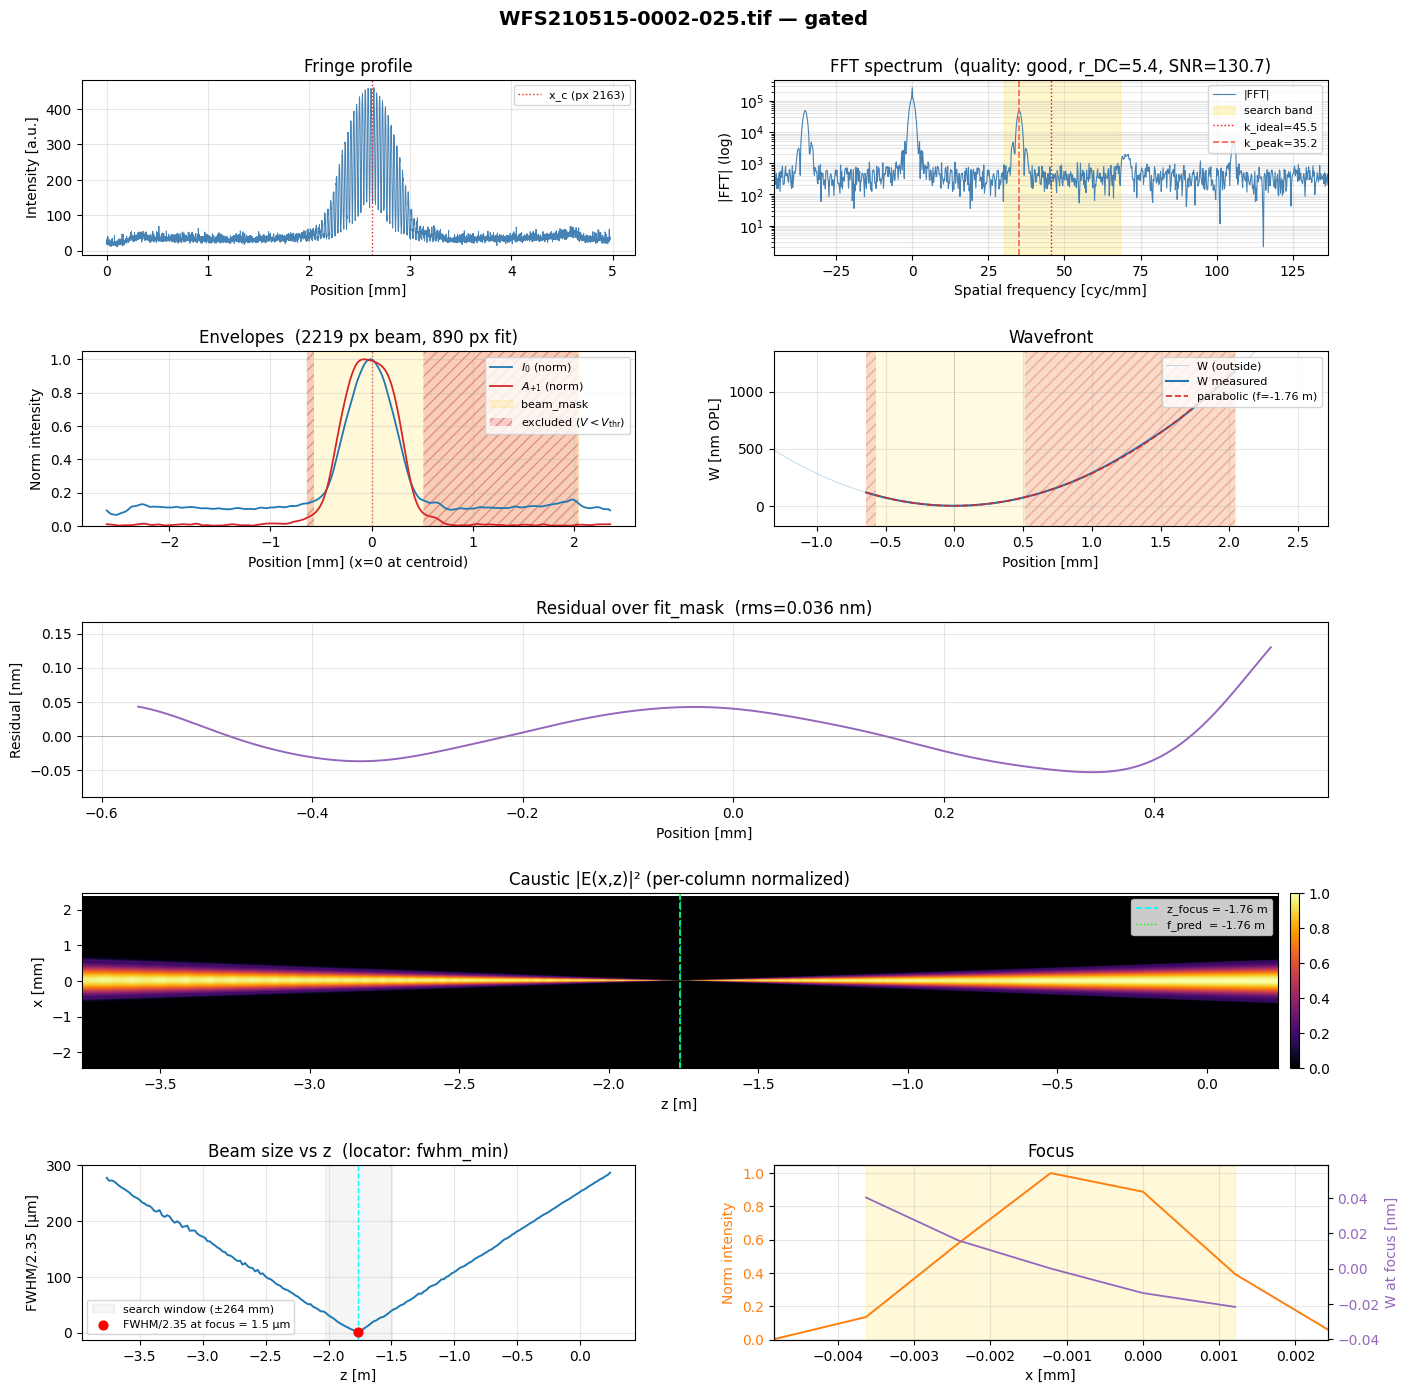


quality flag : good  (r_DC = 5.42, SNR = 130.7)
k_peak/k_ideal: 0.7735
f_pred        : -1.762 m
rms_resid     : 0.036 nm
pv_resid      : 0.183 nm
z_focus       : -1.762 m  (from caustic)
sigma_focus   : 15.54 µm

--- Item A: fit_mask decoupling effect (gated mode) ---
  rms_resid (old, beam_mask as fit domain): 2.479 nm
  rms_resid (new, fit_mask = beam ∩ trust): 0.036 nm
  improvement factor                      : 69.2×
  n_fit_px  (fit_mask)                    : 890

--- Caustic-mode invariance check ---
  rms_resid (field_envelope, cell 39)     : 0.035841 nm
  rms_resid (gated,           cell 40)    : 0.035841 nm
  |difference|                            : 0.00e+00 nm
  invariance check                        : PASS


In [74]:
# Stage B — first reconstruction on real data (gated mode)
y_roi = slice(1080, 1200)    # picked from the beam-region zoom

result = wfs.quick_look(
    image, dx_m, grating_pitch_m, wavelength_m, z_gd_m,
    y_roi=y_roi, axis=0,
    propagate=True,
    caustic_amplitude='gated', V_threshold=0.4,
    title=f'{filename} — gated', 
)

# Pass-criterion summary
print()
print(f"quality flag : {result['quality']}  "
      f"(r_DC = {result['dc_carrier_ratio']:.2f}, SNR = {result['carrier_snr']:.1f})")
print(f"k_peak/k_ideal: {result['k_peak']/result['k_ideal']:.4f}")
print(f"f_pred        : {result['f_pred']:+.3f} m")
print(f"rms_resid     : {result['rms_resid_nm']:.3f} nm")
print(f"pv_resid      : {result['pv_resid_nm']:.3f} nm")
print(f"z_focus       : {result['z_focus']:+.3f} m  (from caustic)")
print(f"sigma_focus   : {result['sigma_focus']*1e6:.2f} µm")

RMS_RESID_FIELDENV_COSMIC = result['rms_resid_nm']   # stash for cell-40 invariance check

# --- Item-A baseline comparison + caustic-mode invariance check ---
# fit_mask depends only on beam_mask & trust_mask (both upstream of the
# caustic-mode branch), so rms_resid here must match cell-39's value to
# numerical precision.
BASELINE_RMS_RESID_PREDECOUPLE = 2.479   # nm, COSMIC, pre-decoupling

invariance_diff = abs(result['rms_resid_nm'] - RMS_RESID_FIELDENV_COSMIC)
invariance_ok   = invariance_diff < 1e-9

print()
print("--- Item A: fit_mask decoupling effect (gated mode) ---")
print(f"  rms_resid (old, beam_mask as fit domain): {BASELINE_RMS_RESID_PREDECOUPLE:.3f} nm")
print(f"  rms_resid (new, fit_mask = beam ∩ trust): {result['rms_resid_nm']:.3f} nm")
print(f"  improvement factor                      : "
      f"{BASELINE_RMS_RESID_PREDECOUPLE / result['rms_resid_nm']:.1f}×")
print(f"  n_fit_px  (fit_mask)                    : {result['n_fit_px']}")
print()
print("--- Caustic-mode invariance check ---")
print(f"  rms_resid (field_envelope, cell 39)     : {RMS_RESID_FIELDENV_COSMIC:.6f} nm")
print(f"  rms_resid (gated,           cell 40)    : {result['rms_resid_nm']:.6f} nm")
print(f"  |difference|                            : {invariance_diff:.2e} nm")
print(f"  invariance check                        : {'PASS' if invariance_ok else 'FAIL'}")

[good]  λ=2.04nm  k_peak=35.2 cyc/mm  r_DC=5.4  SNR=130.7  f_pred=-1.76m  RMS_W=355.2nm  RMS_resid=0.036nm  z_focus=-1.76m(fwhm_min)  RMS@focus=0.004nm


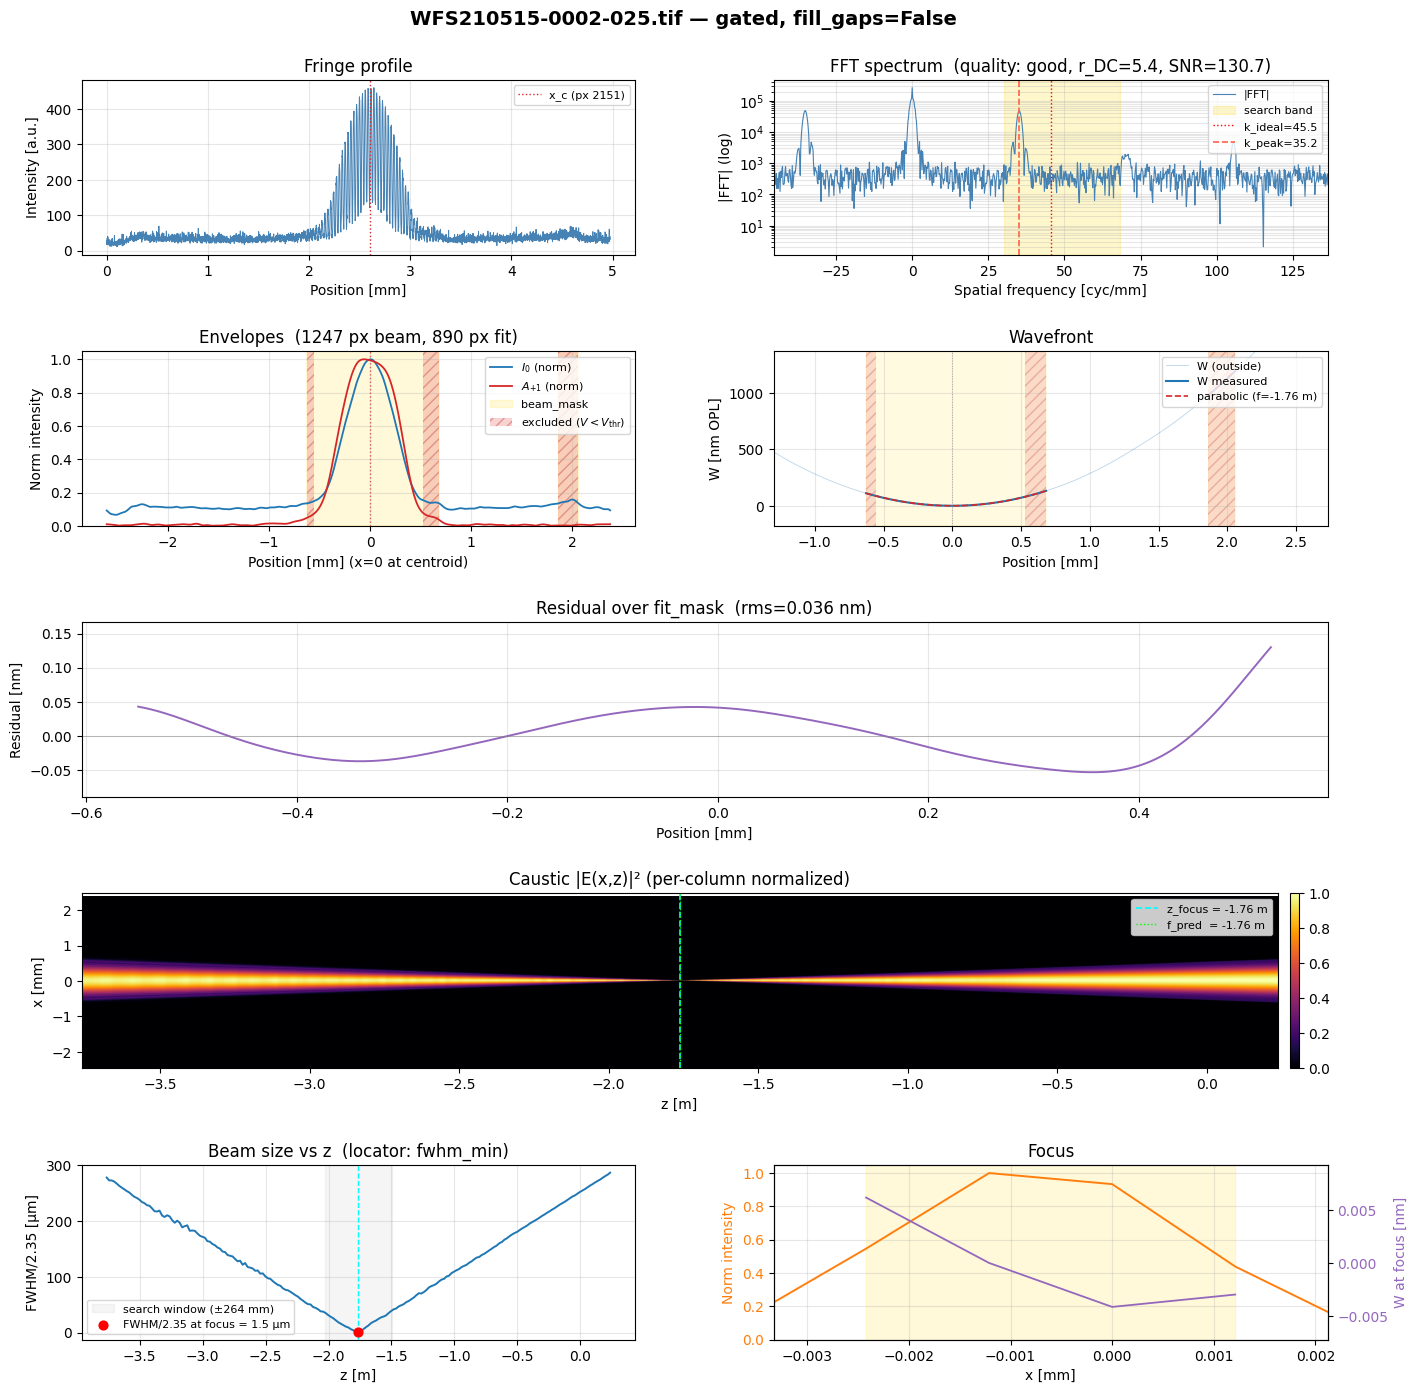


— fill_gaps comparison (gated mode, real data) —
  x_c           : 2163  →  2151  (Δ = -12 px)
  n_mask_px     : 2219  →  1247
  f_pred        : -1.762  →  -1.762 m
  rms_resid     : 0.036  →  0.036 nm
  z_focus       : -1.762  →  -1.762 m
  sigma_focus   : 15.54  →  15.54 µm


In [75]:
# Item 11 archived test: fill_gaps effect on centroid (post-Item-A: independent of fit_mask)
# On Stage B, gap-fill was bridging an off-axis intensity hump into the
# main beam, dragging the centroid off-axis. Setting fill_gaps=False
# restricts the centroid to whatever the raw threshold mask picks up.
#
# We compare against the gated-mode result above (fill_gaps default = True).

result_nofill = wfs.quick_look(
    image, dx_m, grating_pitch_m, wavelength_m, z_gd_m,
    y_roi=y_roi, axis=0,
    propagate=True,
    caustic_amplitude='gated', V_threshold=0.4,
    fill_gaps=False, 
    title=f'{filename} — gated, fill_gaps=False',
)

print()
print('— fill_gaps comparison (gated mode, real data) —')
print(f"  x_c           : {result['x_c']}  →  {result_nofill['x_c']}  "
      f"(Δ = {result_nofill['x_c'] - result['x_c']:+d} px)")
print(f"  n_mask_px     : {result['n_mask_px']}  →  {result_nofill['n_mask_px']}")
print(f"  f_pred        : {result['f_pred']:+.3f}  →  {result_nofill['f_pred']:+.3f} m")
print(f"  rms_resid     : {result['rms_resid_nm']:.3f}  →  {result_nofill['rms_resid_nm']:.3f} nm")
print(f"  z_focus       : {result['z_focus']:+.3f}  →  {result_nofill['z_focus']:+.3f} m")
print(f"  sigma_focus   : {result['sigma_focus']*1e6:.2f}  →  {result_nofill['sigma_focus']*1e6:.2f} µm")

In [76]:
# --- Demo: what protects the parabolic fit? The V mask or fill_gaps? ---
# Three scenarios on the same COSMIC frame, bypassing fit_mask via a
# direct parabolic_focal_fit call:
#
#   1. Item A default        : fit on beam_mask ∩ trust_mask  (= fit_mask)
#   2. No V mask, fill=True  : fit on the gap-filled beam_mask alone
#   3. No V mask, fill=False : fit on the raw, non-gap-filled beam_mask

fit_default = wfs.parabolic_focal_fit(
    result['W_rad'], result['x_m'], wavelength_m,
    mask=result['fit_mask']
)
fit_no_V_filled = wfs.parabolic_focal_fit(
    result['W_rad'], result['x_m'], wavelength_m,
    mask=result['beam_mask']
)
fit_no_V_unfilled = wfs.parabolic_focal_fit(
    result_nofill['W_rad'], result_nofill['x_m'], wavelength_m,
    mask=result_nofill['beam_mask']
)

print()
print('— Bypassing the V/trust_mask: what protects the fit? —')
print()
print(f"{'scenario':<54} {'n_mask':>8} {'rms_resid [nm]':>18}")
print('-' * 82)
print(f"{'1. Item A default (fit_mask = beam_mask ∩ trust)':<54} "
      f"{result['n_fit_px']:>8} {fit_default['rms_resid_nm']:>18.3f}")
print(f"{'2. No V mask, fill_gaps=True (gap-filled beam_mask)':<54} "
      f"{result['n_mask_px']:>8} {fit_no_V_filled['rms_resid_nm']:>18.3f}")
print(f"{'3. No V mask, fill_gaps=False (raw beam_mask)':<54} "
      f"{result_nofill['n_mask_px']:>8} {fit_no_V_unfilled['rms_resid_nm']:>18.3f}")
print()
print("Reading:")
print("  • Scenario 2 reproduces the pre-Item-A baseline (~2.479 nm) —")
print("    the original failure mode.")
print("  • Scenario 3 (fill_gaps=False alone) gives partial relief but")
print("    does not fully exclude polluting wing structure if I0 in those")
print("    regions exceeds the centroid threshold.")
print("  • Scenario 1 (V mask active) is the actual fix.")


— Bypassing the V/trust_mask: what protects the fit? —

scenario                                                 n_mask     rms_resid [nm]
----------------------------------------------------------------------------------
1. Item A default (fit_mask = beam_mask ∩ trust)            890              0.036
2. No V mask, fill_gaps=True (gap-filled beam_mask)        2219              2.479
3. No V mask, fill_gaps=False (raw beam_mask)              1247              0.351

Reading:
  • Scenario 2 reproduces the pre-Item-A baseline (~2.479 nm) —
    the original failure mode.
  • Scenario 3 (fill_gaps=False alone) gives partial relief but
    does not fully exclude polluting wing structure if I0 in those
    regions exceeds the centroid threshold.
  • Scenario 1 (V mask active) is the actual fix.


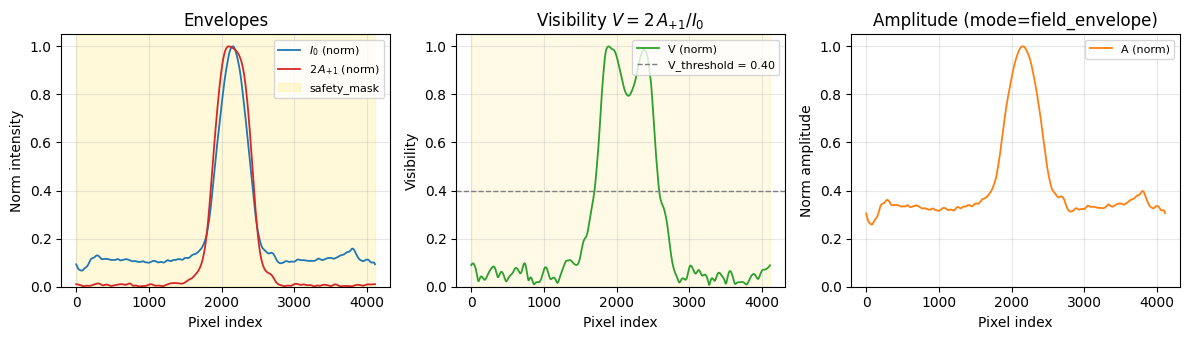

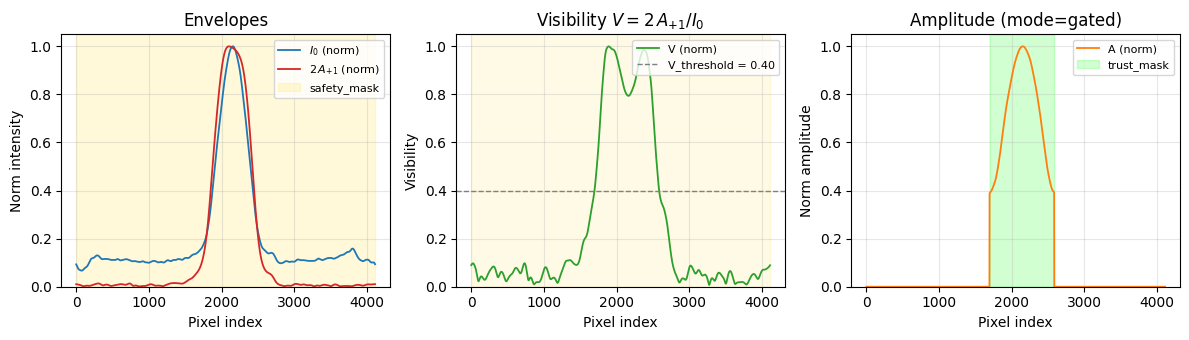

— V profile, inside safety_mask —
  median V          : 0.068
  10–90 % range     : [0.022, 0.891]
  coverage V > 0.4  :  21.6 %
  coverage V > 0.5  :  20.1 %
  coverage V > 0.6  :  18.8 %
  trust_mask size   : 890 px (21.6% of safety_mask)


In [65]:
# --- B5: V profile inspection on the real-data frame ---

# Pull envelopes from B3's result dict (reconstruct_single stored them).
I0_real = result['I0']
A1_real = result['A1']

dbg_fe = wfs.build_caustic_amplitude(
    I0_real, A1_real,
    mode='field_envelope',
    V_threshold=0.4,
    debug=True, plot=True,
)
dbg_g = wfs.build_caustic_amplitude(
    I0_real, A1_real,
    mode='gated',
    V_threshold=0.4,
    debug=True, plot=True,
)

# Quantitative V-profile summary (V is identical between modes;
# use either dbg)
V         = dbg_fe['V']
safety_mask = dbg_fe['safety_mask']
V_in_beam = V[safety_mask]

V_plateau_median = float(np.median(V_in_beam))
V_plateau_p10    = float(np.percentile(V_in_beam, 10))
V_plateau_p90    = float(np.percentile(V_in_beam, 90))

coverage_04 = float((V_in_beam > 0.4).mean())
coverage_05 = float((V_in_beam > 0.5).mean())
coverage_06 = float((V_in_beam > 0.6).mean())

print('— V profile, inside safety_mask —')
print(f'  median V          : {V_plateau_median:.3f}')
print(f'  10–90 % range     : [{V_plateau_p10:.3f}, {V_plateau_p90:.3f}]')
print(f'  coverage V > 0.4  : {coverage_04*100:5.1f} %')
print(f'  coverage V > 0.5  : {coverage_05*100:5.1f} %')
print(f'  coverage V > 0.6  : {coverage_06*100:5.1f} %')
print(f'  trust_mask size   : {dbg_g["trust_mask"].sum()} px '
      f'({dbg_g["trust_mask"].sum()/safety_mask.sum()*100:.1f}% of safety_mask)')

In [66]:
# --- B5b: DC / carrier ratio — Phase G readout + manual cross-check ---

fft_avg = result['fft_avg']
freq    = result['freq']

idx_dc      = int(np.argmin(np.abs(freq)))
amp_dc      = float(np.abs(fft_avg[idx_dc]))
amp_carrier = float(result['k_amp'])

dc_to_carrier = amp_dc / amp_carrier

print('— Phase G candidate baseline —')
print(f'  |FFT(DC)|       : {amp_dc:.1f}')
print(f'  |FFT(k_peak)|   : {amp_carrier:.1f}')
print(f'  DC / carrier    : {dc_to_carrier:.3f}')
print(f'  (lower = better fringe contrast; clean COSMIC baseline)')

# Cross-check against Phase G's library-computed values.
# reconstruct_single now exposes dc_carrier_ratio and carrier_snr in result.
print()
print(f'  Library r_DC    : {result["dc_carrier_ratio"]:.3f}  '
      f'(manual: {dc_to_carrier:.3f}, '
      f'match: {np.isclose(result["dc_carrier_ratio"], dc_to_carrier)})')
print(f'  Library SNR     : {result["carrier_snr"]:.1f}  (new — Phase G)')
print(f'  Library quality : {result["quality"]!r}')

— Phase G candidate baseline —
  |FFT(DC)|       : 266275.9
  |FFT(k_peak)|   : 49118.0
  DC / carrier    : 5.421
  (lower = better fringe contrast; clean COSMIC baseline)

  Library r_DC    : 5.421  (manual: 5.421, match: True)
  Library SNR     : 130.7  (new — Phase G)
  Library quality : 'good'


### Focus locator 

(Fix 2026-06-09)


[good]  λ=2.04nm  k_peak=35.2 cyc/mm  r_DC=5.4  SNR=130.7  f_pred=-1.76m  RMS_W=343.5nm  RMS_resid=0.036nm  z_focus=-1.76m(fwhm_min)  RMS@focus=0.061nm


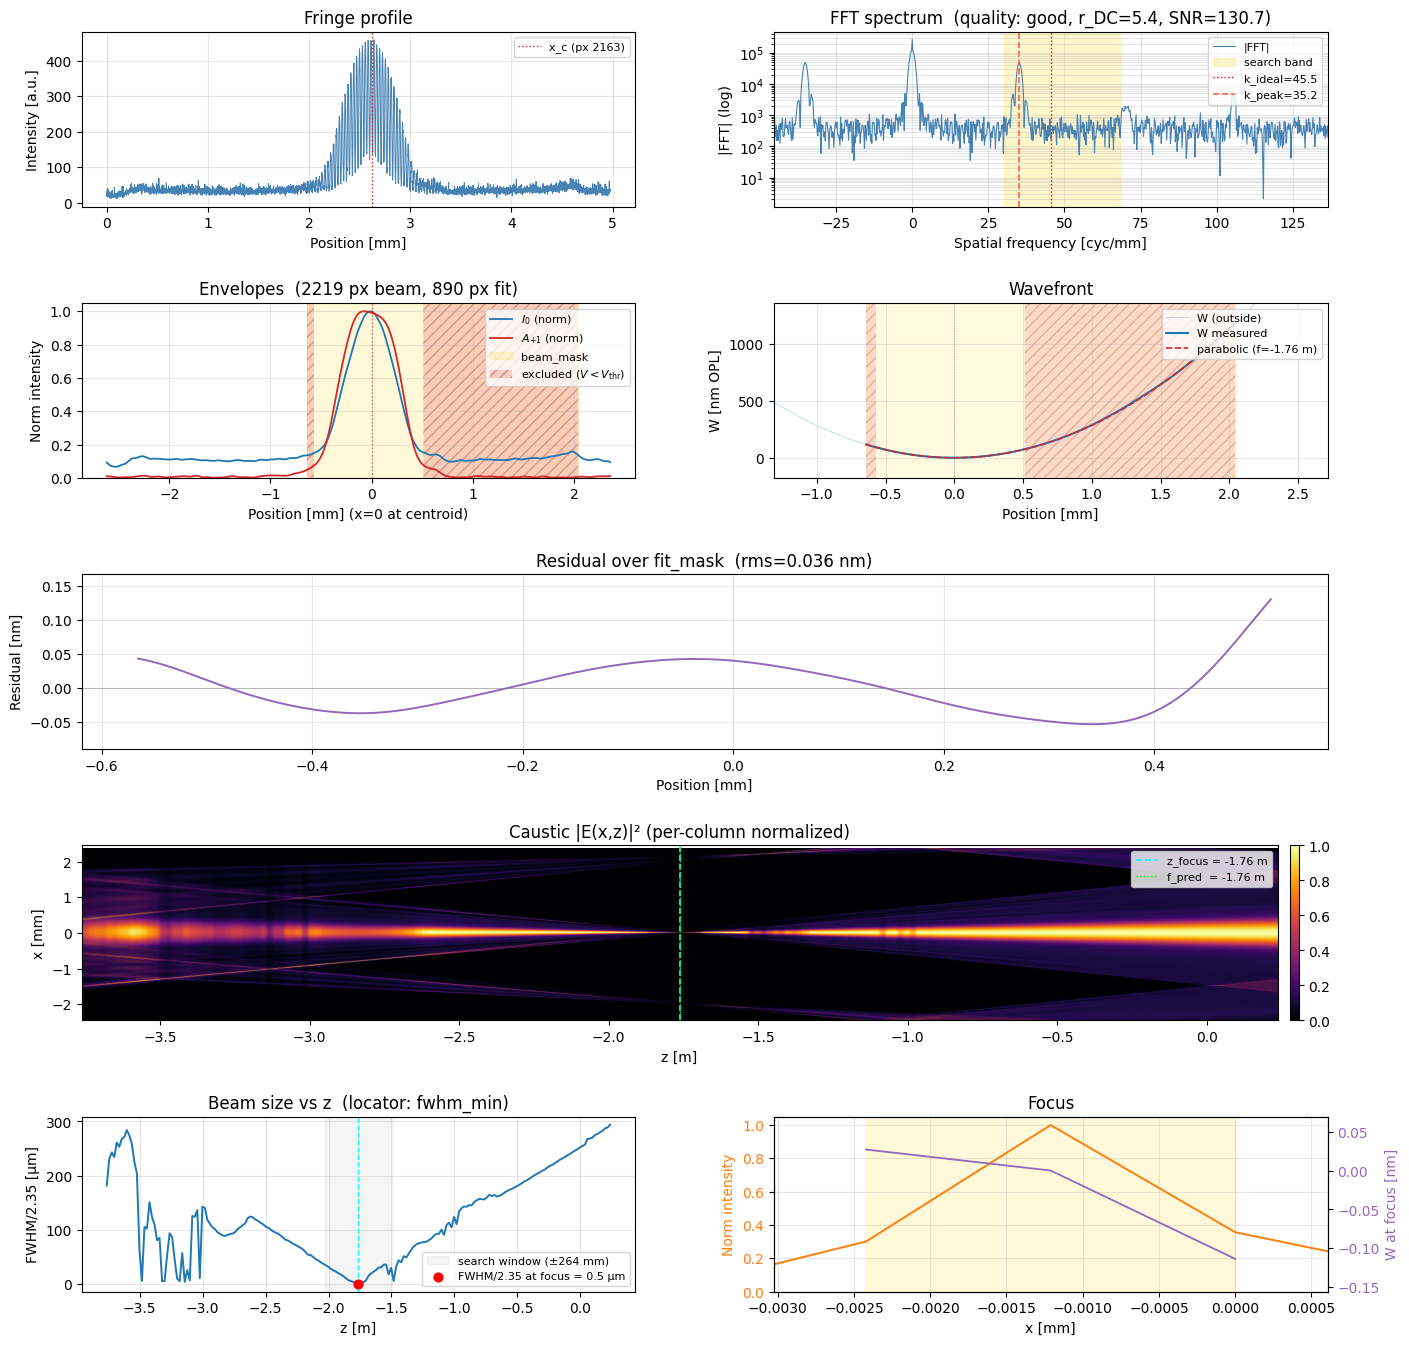

/Users/francisho/Library/CloudStorage/OneDrive-UCSanDiego/Research/Projects/nabla/wfs-als531/wfs_live.py:112: RuntimeWarning: propagate_to_focus: sigma_min minimum landed on the search window boundary (z=-2.022 m, window ±0.264 m around f_pred=-1.762 m).
  


[good]  λ=2.04nm  k_peak=35.2 cyc/mm  r_DC=5.4  SNR=130.7  f_pred=-1.76m  RMS_W=343.5nm  RMS_resid=0.036nm  z_focus=-2.02m(sigma_min) *EDGE*  RMS@focus=328.370nm


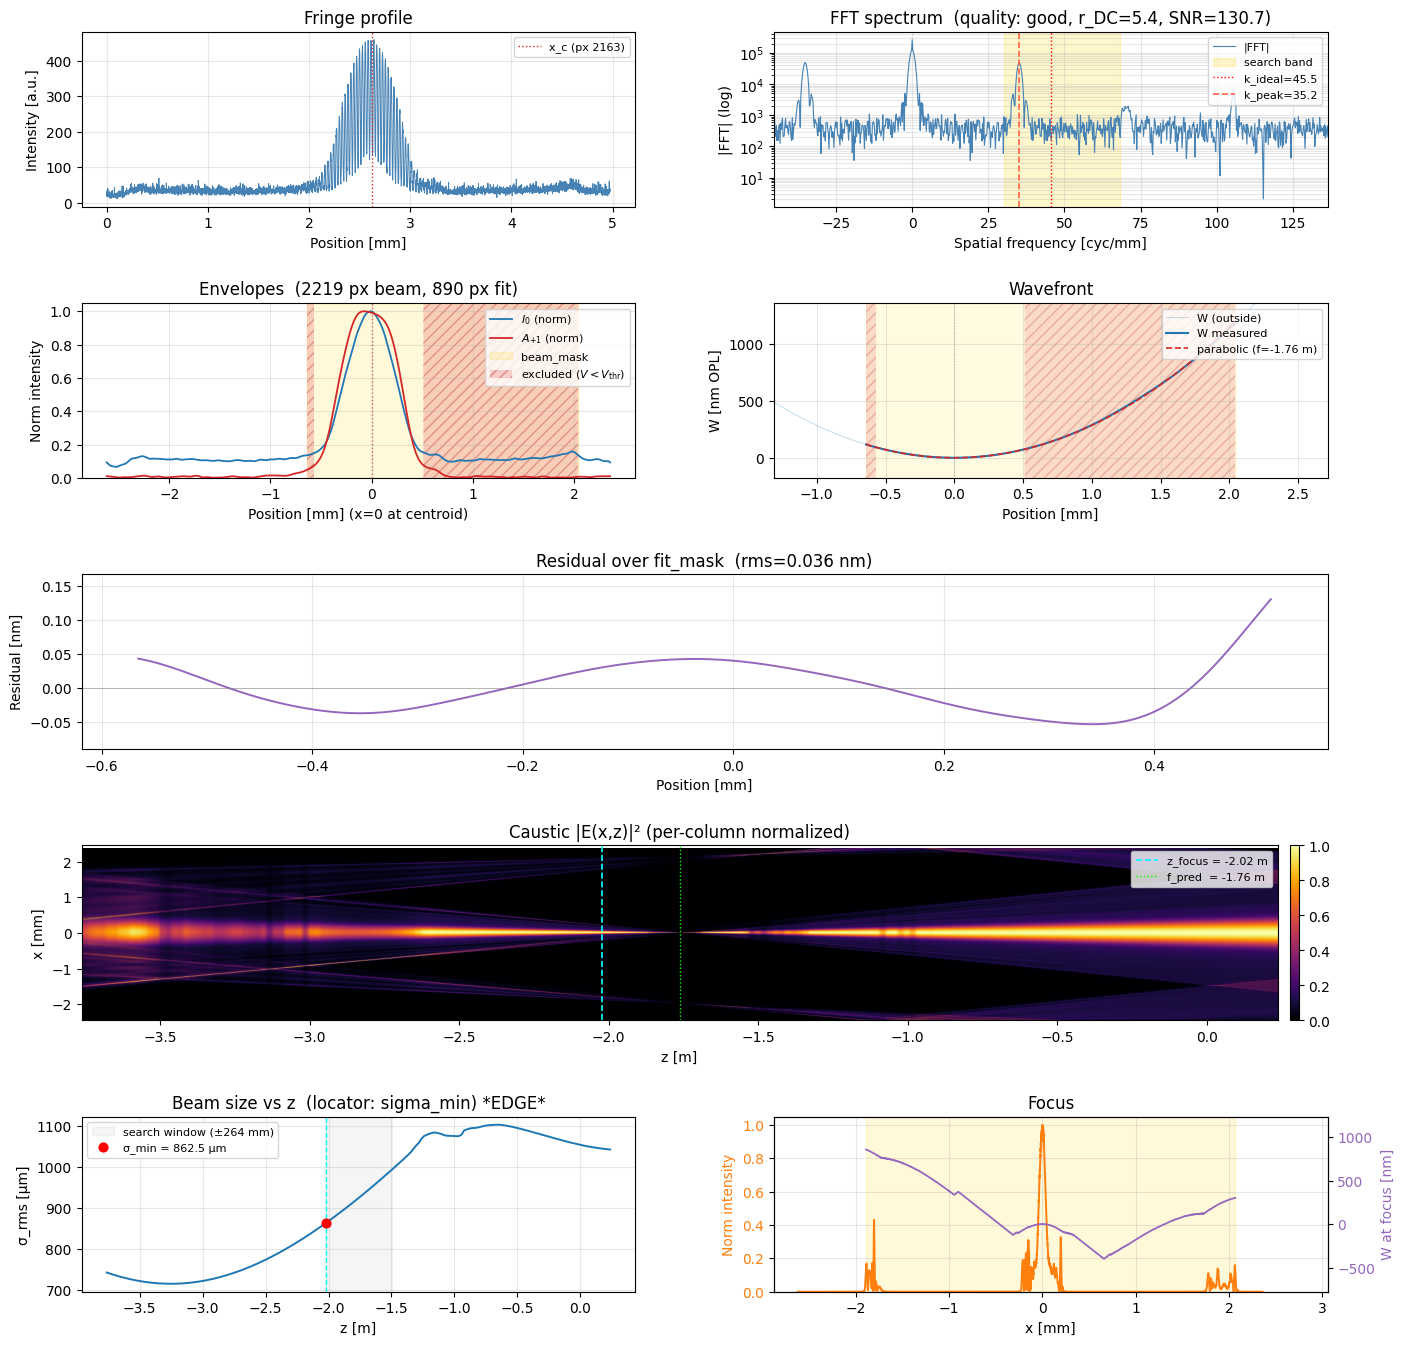

[good]  λ=2.04nm  k_peak=35.2 cyc/mm  r_DC=5.4  SNR=130.7  f_pred=-1.76m  RMS_W=343.5nm  RMS_resid=0.036nm  z_focus=-1.76m(geometric)  RMS@focus=0.061nm


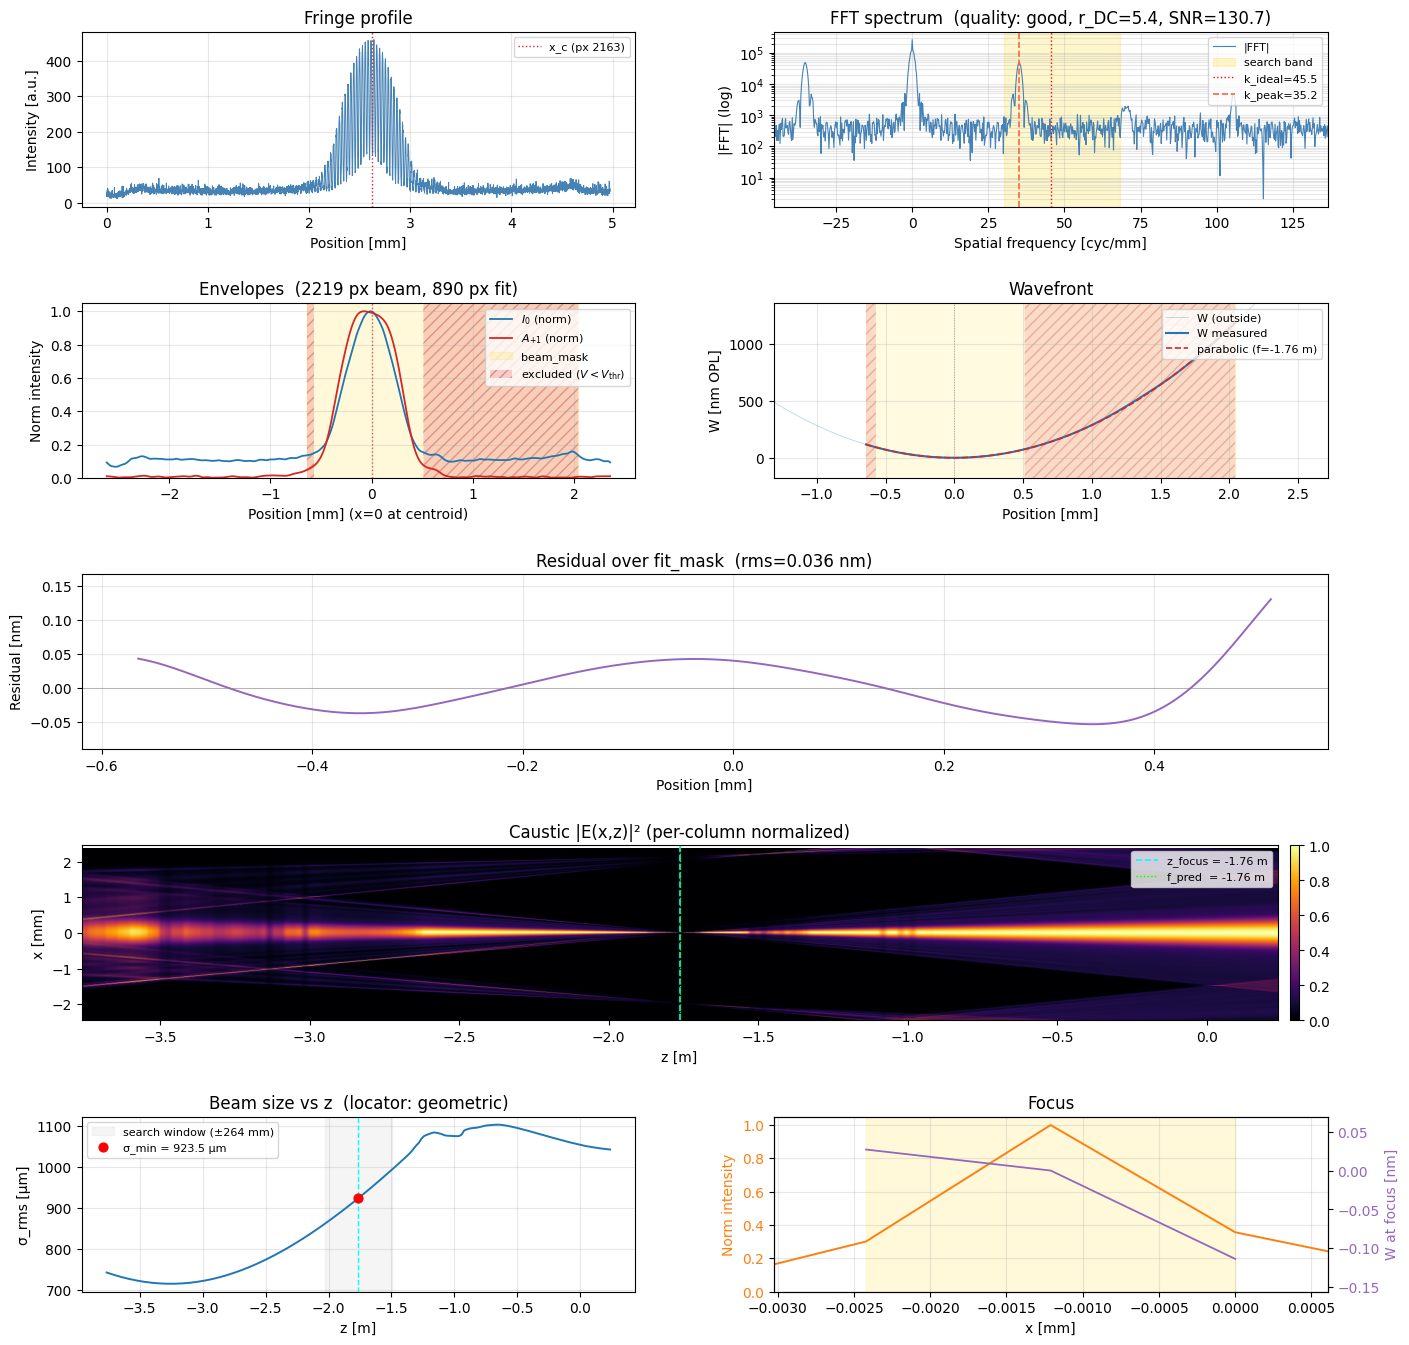

locator         z_focus [m]     Δ vs f_pred [mm]     sigma_focus [µm]     fwhm/2.35 [µm]    edge?
-----------------------------------------------------------------------------------------------
fwhm_min             -1.762                 +0.0               923.48              0.515       no
sigma_min            -2.022               -260.0               862.48             34.513      YES
geometric            -1.762                 +0.0               923.48              0.515       no

f_pred (from parabolic fit) : -1.762 m
Interpretation:
  • fwhm_min should agree with f_pred (sharp peak at geometric focus)
  • geometric is by definition f_pred snapped to nearest z
  • sigma_min may disagree (wings dominate σ in field_envelope mode)


In [79]:
# --- B-verify-1: focus locator comparison on COSMIC ---
# Run the same field_envelope frame with all three locators and compare.
# Expected: fwhm_min and geometric agree (≈ f_pred). sigma_min disagrees
# (wing-runaway) — bounded search may or may not save it depending on
# halfwidth.

locator_results = {}
for loc in ['fwhm_min', 'sigma_min', 'geometric']:
    r = wfs.quick_look(
        image, dx_m, grating_pitch_m, wavelength_m, z_gd_m,
        y_roi=y_roi, axis=0,
        propagate=True,
        caustic_amplitude='field_envelope',
        focus_locator=loc,
        title=None,
    )
    locator_results[loc] = r
    plt.close('all')   # suppress per-call plots; we just want the numbers

f_pred = locator_results['fwhm_min']['f_pred']
print(f"{'locator':<12} {'z_focus [m]':>14} {'Δ vs f_pred [mm]':>20} "
      f"{'sigma_focus [µm]':>20} {'fwhm/2.35 [µm]':>18} {'edge?':>8}")
print('-' * 95)
for loc, r in locator_results.items():
    dz_mm = (r['z_focus'] - f_pred) * 1e3
    sig   = r['sigma_focus'] * 1e6
    fw    = r['fwhm_focus'] * 1e6 if not np.isnan(r['fwhm_focus']) else float('nan')
    edge  = 'YES' if r['focus_at_edge'] else 'no'
    print(f"{loc:<12} {r['z_focus']:>+14.3f} {dz_mm:>+20.1f} "
          f"{sig:>20.2f} {fw:>18.3f} {edge:>8}")

print(f"\nf_pred (from parabolic fit) : {f_pred:+.3f} m")
print("Interpretation:")
print("  • fwhm_min should agree with f_pred (sharp peak at geometric focus)")
print("  • geometric is by definition f_pred snapped to nearest z")
print("  • sigma_min may disagree (wings dominate σ in field_envelope mode)")

## Access Data from the Server

__Note:__ We tried read data from db with `tiled.__version__='0.2.9'`, but it failed; had to reinstall a 0.2.1 version to make it work. 

In [80]:
# --- Server connection ---
api_key_path = "/Users/francisho/Documents/TILED_SINGLE_USER_API_KEY.txt"   # Change this path to where your API key is stored 

with open(api_key_path, "r") as f:
    api_key = f.read().strip()

if not api_key:
    raise ValueError("API key file is empty or not found.")

tiled_client = from_uri("http://131.243.80.226:8000", api_key=api_key)

KeyboardInterrupt: 

__Important scans files:__

`Uid = '88dd6a7f-0338-446f-8185-fa9e004add04'`: A grid scan for `RE(grid_scan([basler_5472], mono_energy, 7000, 10000, 7, Obender, -2000, -0000, 11, snake_axes=False, md=md))`


In [ ]:
# --- Dataset ---
DATASET_ID = '88dd6a7f-0338-446f-8185-fa9e004add04'
db = tiled_client[DATASET_ID]

# Metadata
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
exp_time_s = db.metadata['start']['exposure time [s]']
pixel_size_um = db.metadata['start']['pixel size [um]']
binning = db.metadata['start']['binning']
effective_pixel_size_um = db.metadata['start']['effective pixel size [um]']
camera_model = db.metadata['start']['camera model']
objective_model = db.metadata['start']['objective model']

print(f"Camera:          {camera_model}")
print(f"Objective:       {objective_model}")
print(f"Pixel size:      {pixel_size_um} µm  (binning: {binning}×)")
print(f"Effective pixel: {effective_pixel_size_um} µm")
print(f"Exposure time:   {exp_time_s} s")
print(f"WFS chip position (mm): {wfs_chip_pos_mm}")


In [ ]:
# Arrays (slow, ~20 seconds to load) 
images    = db['primary']['basler_5472_image'].read()
energy_eV = db['primary']['mono_energy_energy_eV'].read()
bender_um = db['primary']['bender_um'].read()

print(f"Images shape: {images.shape}  (n_frames × height × width)")
print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
print(f"       shape: {energy_eV.shape}")
print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
print(f"       shape: {bender_um.shape}")

## Reconstruction

In [ ]:
# --- Physical parameters (BL 5.3.1 hard X-ray grid scan) ---

# Detector geometry (from db metadata, read above)
dx_m = effective_pixel_size_um * 1e-6

# Grating + propagation geometry (FILL IN from beamline records)
grating_pitch_m = 7e-6                            # Grating pitch from fabrication [m]
z_gd_m          = 0.3                             # Grating-to-detector distance [m]

# Per-frame wavelength array — energy varies across the scan
wavelength_m_arr = np.array([wfs.energy_eV_to_wavelength_m(e) for e in energy_eV])

print(f"dx (effective):   {dx_m*1e6:.3f} µm")
print(f"Grating pitch:    {grating_pitch_m*1e6:.1f} µm")
print(f"z_gd:             {z_gd_m*1e3:.0f} mm")
print(f"Wavelength range: {wavelength_m_arr.min()*1e9:.4f} – "
      f"{wavelength_m_arr.max()*1e9:.4f} nm  "
      f"(E = {energy_eV.min():.0f} – {energy_eV.max():.0f} eV)")

In [ ]:
# --- Hard X-ray single-frame sanity check ---
# First reconstruction at BL 5.3.1. Pick a frame from the strong-fringe
# region of the survey (top-left of grid, large bender + mid energy) to
# maximize chance of clean recovery. If this fails, the grid scan will.
#
# Defaults follow Stage B (COSMIC) findings:
#   caustic_amplitude='gated'  — field_envelope runs away on real wings
#   fill_gaps=False            — gap-fill bridges off-axis structure

idx   = 23                                 # frame: E=8000 eV, bender=-1800 µm
y_roi = slice(470, 486)                    # fringe band in y

result = wfs.quick_look(
    images[idx], dx_m, grating_pitch_m, wavelength_m_arr[idx], z_gd_m,
    y_roi=y_roi, axis=1,
    propagate=True,
    caustic_amplitude='gated', V_threshold=0.4,
    fill_gaps=False,
    title=f'idx={idx}  E={energy_eV[idx]:.0f} eV  bender={bender_um[idx]:.0f} µm',
)

print(f"quality flag : {result['quality']}  "
      f"(r_DC = {result['dc_carrier_ratio']:.2f}, SNR = {result['carrier_snr']:.1f})")
print(f"k_peak/k_ideal: {result['k_peak']/result['k_ideal']:.4f}  "
      f"(carrier shift relative to grating)")
print(f"f_pred        : {result['f_pred']:+.3f} m")
print(f"rms_W         : {result['rms_W_nm']:.1f} nm  (raw)")
print(f"rms_resid     : {result['rms_resid_nm']:.3f} nm  (defocus removed)")
print(f"z_focus       : {result['z_focus']:+.3f} m")
print(f"sigma_focus   : {result['sigma_focus']*1e6:.2f} µm")

In [ ]:
# --- Hard X-ray single-frame sanity check ---
# First reconstruction at BL 5.3.1. Pick a frame from the strong-fringe
# region of the survey (top-left of grid, large bender + mid energy) to
# maximize chance of clean recovery. If this fails, the grid scan will.
#
# Defaults follow Stage B (COSMIC) findings:
#   caustic_amplitude='gated'  — field_envelope runs away on real wings
#   fill_gaps=False            — gap-fill bridges off-axis structure

idx   = 30                                 # frame: E=8000 eV, bender=-1800 µm
y_roi = slice(470, 486)                    # fringe band in y

result = wfs.quick_look(
    images[idx], dx_m, grating_pitch_m, wavelength_m_arr[idx], z_gd_m,
    y_roi=y_roi, axis=1,
    propagate=True,
    caustic_amplitude='gated', V_threshold=0.4,
    fill_gaps=False,
    title=f'idx={idx}  E={energy_eV[idx]:.0f} eV  bender={bender_um[idx]:.0f} µm',
)

print(f"quality flag : {result['quality']}  "
      f"(r_DC = {result['dc_carrier_ratio']:.2f}, SNR = {result['carrier_snr']:.1f})")
print(f"k_peak/k_ideal: {result['k_peak']/result['k_ideal']:.4f}  "
      f"(carrier shift relative to grating)")
print(f"f_pred        : {result['f_pred']:+.3f} m")
print(f"rms_W         : {result['rms_W_nm']:.1f} nm  (raw)")
print(f"rms_resid     : {result['rms_resid_nm']:.3f} nm  (defocus removed)")
print(f"z_focus       : {result['z_focus']:+.3f} m")
print(f"sigma_focus   : {result['sigma_focus']*1e6:.2f} µm")

In [ ]:
# --- Subsection 4.1: Batch at fixed energy E=8000 eV, bender sweep ---
# Indices: 22..32 (e=2 → E=8000 eV; bender index 0..10 → −2000..0 µm)

E_fixed_eV    = 8000
idx_list_4p1  = [b + 11*2 for b in range(11)]  # 22..32
bender_list   = bender_um[idx_list_4p1]

metrics_4p1 = []
for idx in idx_list_4p1:
    r = wfs.reconstruct_single(
        images[idx], dx_m, grating_pitch_m, wavelength_m_arr[idx], z_gd_m,
        y_roi=y_roi, axis=1,
        propagate=False,                       # skip caustic — Phase G is FFT-stage
        fill_gaps=False,
        verbose=False,
        # band_factor=2,
    )
    metrics_4p1.append(dict(
        idx       = idx,
        bender_um = bender_um[idx],
        E_eV      = energy_eV[idx],
        k_peak    = r['k_peak'],
        k_ideal   = r['k_ideal'],
        k_amp     = r['k_amp'],
        dc_amp    = r['dc_amp'],
        bg_amp    = r['bg_amp'],
        r_DC      = r['dc_carrier_ratio'],
        SNR       = r['carrier_snr'],
        quality   = r['quality'],
        f_pred    = r['f_pred'],
        rms_resid = r['rms_resid_nm'],
        rms_W     = r['rms_W_nm'],
    ))

# Pull arrays for plotting
bender_arr = np.array([m['bender_um']  for m in metrics_4p1])
r_DC_arr   = np.array([m['r_DC']       for m in metrics_4p1])
SNR_arr    = np.array([m['SNR']        for m in metrics_4p1])
fpred_arr  = np.array([m['f_pred']     for m in metrics_4p1])
resid_arr  = np.array([m['rms_resid']  for m in metrics_4p1])
quality_arr = np.array([m['quality']   for m in metrics_4p1])

# Quality flag colors
q_color = {'good': 'tab:green', 'ok': 'tab:orange', 'bad': 'tab:red'}
colors  = [q_color[q] for q in quality_arr]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

ax = axes[0, 0]
ax.scatter(bender_arr, r_DC_arr, c=colors, s=60, edgecolors='black', linewidths=0.5)
ax.axhline(50,  color='gray', ls=':', label='r_good = 50')
ax.axhline(200, color='gray', ls='--', label='r_bad = 200')
ax.set_yscale('log')
ax.set_xlabel('Bender [µm]')
ax.set_ylabel('r_DC = |F(0)| / |F(k_peak)|')
ax.set_title('Phase G: DC/carrier ratio')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.scatter(bender_arr, SNR_arr, c=colors, s=60, edgecolors='black', linewidths=0.5)
ax.set_yscale('log')
ax.set_xlabel('Bender [µm]')
ax.set_ylabel('SNR = |F(k_peak)| / bg_amp')
ax.set_title('Phase G: carrier SNR')
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.scatter(bender_arr, fpred_arr, c=colors, s=60, edgecolors='black', linewidths=0.5)
ax.set_xlabel('Bender [µm]')
ax.set_ylabel('f_pred [m]')
ax.set_title('Predicted focus vs bender')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.scatter(bender_arr, resid_arr, c=colors, s=60, edgecolors='black', linewidths=0.5)
ax.set_xlabel('Bender [µm]')
ax.set_ylabel('rms_resid [nm]')
ax.set_title('Residual wavefront error')
ax.grid(True, alpha=0.3)

fig.suptitle(f'Bender sweep at E = {E_fixed_eV} eV  (idx {idx_list_4p1[0]}..{idx_list_4p1[-1]})',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary table
print(f"{'idx':>4} {'bender':>8} {'r_DC':>8} {'SNR':>8} {'quality':>8} "
      f"{'f_pred':>9} {'resid':>8}")
for m in metrics_4p1:
    print(f"{m['idx']:>4} {m['bender_um']:>+8.0f} {m['r_DC']:>8.1f} "
          f"{m['SNR']:>8.1f} {m['quality']:>8} "
          f"{m['f_pred']:>+9.3f} {m['rms_resid']:>8.3f}")

In [ ]:
# --- Subsection 4.2: Batch at fixed bender = −1800 µm, energy sweep ---
# Indices: 1, 12, 23, 34, 45, 56, 67 (b=1 → bender=−1800; e=0..6)

bender_fixed_um  = -1800
idx_list_4p2     = [1 + 11*e for e in range(7)]  # 1, 12, 23, 34, 45, 56, 67

metrics_4p2 = []
for idx in idx_list_4p2:
    r = wfs.reconstruct_single(
        images[idx], dx_m, grating_pitch_m, wavelength_m_arr[idx], z_gd_m,
        y_roi=y_roi, axis=1,
        propagate=False,
        fill_gaps=False,
        band_factor=2,
        verbose=False,
    )
    metrics_4p2.append(dict(
        idx       = idx,
        bender_um = bender_um[idx],
        E_eV      = energy_eV[idx],
        k_peak    = r['k_peak'],
        k_ideal   = r['k_ideal'],
        k_amp     = r['k_amp'],
        r_DC      = r['dc_carrier_ratio'],
        SNR       = r['carrier_snr'],
        quality   = r['quality'],
        f_pred    = r['f_pred'],
        rms_resid = r['rms_resid_nm'],
        rms_W     = r['rms_W_nm'],
    ))

E_arr_4p2     = np.array([m['E_eV']      for m in metrics_4p2])
r_DC_arr_4p2  = np.array([m['r_DC']      for m in metrics_4p2])
SNR_arr_4p2   = np.array([m['SNR']       for m in metrics_4p2])
fpred_arr_4p2 = np.array([m['f_pred']    for m in metrics_4p2])
resid_arr_4p2 = np.array([m['rms_resid'] for m in metrics_4p2])
quality_arr_4p2 = np.array([m['quality'] for m in metrics_4p2])
colors_4p2    = [q_color[q] for q in quality_arr_4p2]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

ax = axes[0, 0]
ax.scatter(E_arr_4p2, r_DC_arr_4p2, c=colors_4p2, s=60, edgecolors='black', linewidths=0.5)
ax.axhline(50,  color='gray', ls=':', label='r_good = 50')
ax.axhline(200, color='gray', ls='--', label='r_bad = 200')
ax.set_yscale('log')
ax.set_xlabel('Energy [eV]')
ax.set_ylabel('r_DC')
ax.set_title('Phase G: DC/carrier ratio')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.scatter(E_arr_4p2, SNR_arr_4p2, c=colors_4p2, s=60, edgecolors='black', linewidths=0.5)
ax.set_yscale('log')
ax.set_xlabel('Energy [eV]')
ax.set_ylabel('SNR')
ax.set_title('Phase G: carrier SNR')
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.scatter(E_arr_4p2, fpred_arr_4p2, c=colors_4p2, s=60, edgecolors='black', linewidths=0.5)
ax.set_xlabel('Energy [eV]')
ax.set_ylabel('f_pred [m]')
ax.set_title('Predicted focus vs energy')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.scatter(E_arr_4p2, resid_arr_4p2, c=colors_4p2, s=60, edgecolors='black', linewidths=0.5)
ax.set_xlabel('Energy [eV]')
ax.set_ylabel('rms_resid [nm]')
ax.set_title('Residual wavefront error')
ax.grid(True, alpha=0.3)

fig.suptitle(f'Energy sweep at bender = {bender_fixed_um} µm  (idx {idx_list_4p2})',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"{'idx':>4} {'E_eV':>6} {'r_DC':>8} {'SNR':>8} {'quality':>8} "
      f"{'f_pred':>9} {'resid':>8}")
for m in metrics_4p2:
    print(f"{m['idx']:>4} {m['E_eV']:>6.0f} {m['r_DC']:>8.1f} "
          f"{m['SNR']:>8.1f} {m['quality']:>8} "
          f"{m['f_pred']:>+9.3f} {m['rms_resid']:>8.3f}")

In [ ]:
# --- Subsection 4.3: Wavefront overlay, bender sweep at E=8000 eV ---
# Re-run batch and capture wavefronts. Bad frames flagged with dashed line.

idx_list_4p3 = idx_list_4p1   # 22..32

# Re-run capturing W_nm and x_m
results_4p3 = []
for idx in idx_list_4p3:
    r = wfs.reconstruct_single(
        images[idx], dx_m, grating_pitch_m, wavelength_m_arr[idx], z_gd_m,
        y_roi=y_roi, axis=1,
        propagate=False,
        fill_gaps=False,
        verbose=False,
    )
    results_4p3.append(r)

# Plot
fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(idx_list_4p3)))

for k, (idx, r) in enumerate(zip(idx_list_4p3, results_4p3)):
    bender = bender_um[idx]
    is_bad = (r['quality'] == 'bad')
    label  = f"{bender:+5.0f} µm  [{r['quality']}]"
    lw     = 1.2 if is_bad else 1.8
    ls     = '--' if is_bad else '-'
    alpha  = 0.5 if is_bad else 0.9
    ax.plot(r['x_m'] * 1e3, r['W_nm'],
            color=colors[k], lw=lw, ls=ls, alpha=alpha, label=label)

ax.set_xlabel('Position [mm]  (x=0 at centroid)')
ax.set_ylabel('Wavefront W [nm OPL]')
ax.set_title(f'Bender sweep at E = 8000 eV  (dashed = bad quality)')
ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
ax.axvline(0, color='gray', lw=0.5, alpha=0.5)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=2, loc='best', title='bender')
plt.tight_layout()
plt.show()

In [ ]:
# --- Subsection 4.4: Wavefront overlay, energy sweep at bender=−1800 µm ---

idx_list_4p4 = idx_list_4p2   # 1, 12, 23, 34, 45, 56, 67

results_4p4 = []
for idx in idx_list_4p4:
    r = wfs.reconstruct_single(
        images[idx], dx_m, grating_pitch_m, wavelength_m_arr[idx], z_gd_m,
        y_roi=y_roi, axis=1,
        propagate=False,
        fill_gaps=False,
        verbose=False,
    )
    results_4p4.append(r)

fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.plasma(np.linspace(0, 1, len(idx_list_4p4)))

for k, (idx, r) in enumerate(zip(idx_list_4p4, results_4p4)):
    E      = energy_eV[idx]
    is_bad = (r['quality'] == 'bad')
    label  = f"{E:5.0f} eV  [{r['quality']}]"
    lw     = 1.2 if is_bad else 1.8
    ls     = '--' if is_bad else '-'
    alpha  = 0.5 if is_bad else 0.9
    ax.plot(r['x_m'] * 1e3, r['W_nm'],
            color=colors[k], lw=lw, ls=ls, alpha=alpha, label=label)

ax.set_xlabel('Position [mm]  (x=0 at centroid)')
ax.set_ylabel('Wavefront W [nm OPL]')
ax.set_title(f'Energy sweep at bender = −1800 µm  (dashed = bad quality)')
ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
ax.axvline(0, color='gray', lw=0.5, alpha=0.5)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='best', title='Energy')
plt.tight_layout()
plt.show()

# NOTES
